I. Introduction

1. Background:

	Recently, energy efficiency is becoming one of the most pressing global challenges, especially in building energy consumption, totaling to 40% of the energy consumption, which makes them a significant contributor to green house gas (GHG) emission. Furthermore, as the sustainability initiatives and targets becomes the top priority globally, the ability to accuratey predict buildings' energy demand is needed more than ever to help drive a meaningful environmental and economic improvement. Moreover, the energy sector always face the problem to determine the most efficient energy stored that can satisfy the energy demand of every building. Therefore, to help this problem we woluld  For this project, we will use ASHRAE Great Energy Predictor III Dataset to make a prediction of the energy demand of a building. This dataset is collected from 16 unique sites (site id 0-15), each representating a geographic location across North America and Europe. However, due to time constraint and a massive data (data set has 20M++ entries), for this project, we would only do an energy prediction in Site 1, where we do a random sample of only 20k for our dataset, from the original 550k dataset for site 1.


2. Problem Statement:

	Despite significant global investments in increasing building energy efficiency, the industry faces a critical measurement challenge, which is on how to accurately estimate how much energy a building would have consumed had no improvements been made. Without reliable baseline predictions, it is impossible to verify and monetize the actual energy savings achieved by these projects, undermining the financial viability of the entire energy efficiency ecosystem.


3. Objective:

	To make a supervised model machine learning with an algorithm based on regression to predict energy demand as accurately as possible using at least 5 regression models (KNN, SVM, Decision Tree, Random Forest, and Boosting). To conduct comprehensive EDA (exploratory data analysis), identifying important features, building predictive model with the least MAE/RMSE, while also giving insights into the whole project, especially for site 1.

4. Scenario:

	The city (site 1) wants to determine the energy demand of a building newly built to take into account for the grid to adjust the demand

	Specific objective:
	to help the city to estimate how much energy demand does the grid needs to prepare in order to fulfill the needs of the new building.

5. Metrics:

Regression Metrics:

- MAE (Mean Absolute Error), to know the average absolute difference between predicted and actual meter reading
- MSE (Mean Squared Error), this value punish larger errors more heavily
- RMSE (Root Mean Squared Error), same as MSE but rootsquared
- R² (R-squared), this measure how well a model explains variance in data, the higher the value  better
- CV RMSE (Cross-Validated RMSE), RMSE averaged across 5 folds, more reliable than a single train/test split
- CV RMSE Std, standard deviation of CV RMSE across folds to measure model stability
- %MAE (MAE as percentage), MAE relative to the mean meter reading, gives a relative error range
- Overfitting Check (Train R² - Test R²),  difference between train and test R²


II. Import Libraries

The imported libraries would be used in section III to XI.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn

from scipy import stats
from scipy.stats import spearmanr, pearsonr, f_oneway
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score


#for regression type model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR, SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from statsmodels.stats.stattools import durbin_watson


from sklearn.pipeline import Pipeline, make_pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.inspection import permutation_importance

#model metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #this is for regression model type metrics

import shap
import pickle
import json
import dill
import joblib

III. Data Loading

Import the dataset from the source and then make a copy of the original dataset to make sure the original data set is not changed.

In [2]:
#Loading data original
df_ori = pd.read_csv('ashrae_site_1_randomized_20k.csv',delimiter=',')
df_ori

#Making data copy for data cleaning for EDA
df_uncleaned = df_ori.copy()
df_uncleaned

,id,building_id,site_id,primary_use,square_feet,year_built,floor_count,meter,time_stamp,meter_reading,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,13214777,126,1,Education,21539,2004.0,5.0,0,2016-04-28 15:00:00,120.6,10.5,NaN,0.7,NaN,1012.3,220.0,8.2
1,13284987,125,1,Education,16802,1995.0,6.0,0,2016-05-01 04:00:00,141.3,2.7,0.0,2.0,NaN,1028.1,250.0,1.5
2,6042358,112,1,Education,32206,NaN,6.0,0,2016-08-10 04:00:00,0.0,10.9,NaN,7.8,NaN,1024.7,290.0,3.1
3,15884458,107,1,Education,97532,2005.0,10.0,0,2016-08-02 07:00:00,84.3,17.5,NaN,16.3,NaN,1009.6,220.0,5.1
4,14364089,122,1,Education,83043,1991.0,6.0,0,2016-06-08 20:00:00,254.8,20.5,NaN,17.9,NaN,1023.1,10.0,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,7230336,138,1,Public services,118231,NaN,6.0,0,2016-09-21 20:00:00,141.3,17.0,NaN,13.5,NaN,1018.1,160.0,3.1
19996,7009842,139,1,Public services,56629,1900.0,6.0,3,2016-09-14 00:00:00,0.0,21.9,NaN,16.8,NaN,1008.8,50.0,3.1
19997,8176157,138,1,Public services,118231,NaN,6.0,3,2016-10-25 09:00:00,3.9,10.4,NaN,8.8,NaN,1022.8,40.0,2.1
19998,4827289,139,1,Public services,56629,1900.0,6.0,0,2016-06-27 10:00:00,92.3,18.5,NaN,14.3,NaN,1017.7,310.0,3.6


In [3]:
""""
To see the column name, non-null count, and data type info in the data frame
"""
#Explore dataset 1
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  20000 non-null  int64  
 1   building_id         20000 non-null  int64  
 2   site_id             20000 non-null  int64  
 3   primary_use         20000 non-null  object 
 4   square_feet         20000 non-null  int64  
 5   year_built          14940 non-null  float64
 6   floor_count         20000 non-null  float64
 7   meter               20000 non-null  int64  
 8   time_stamp          20000 non-null  object 
 9   meter_reading       20000 non-null  float64
 10  air_temperature     19996 non-null  float64
 11  cloud_coverage      3960 non-null   float64
 12  dew_temperature     19996 non-null  float64
 13  precip_depth_1_hr   0 non-null      float64
 14  sea_level_pressure  19879 non-null  float64
 15  wind_direction      19994 non-null  float64
 16  wind

As seen from the information above, it can be seen that there are several columns with null values. This can be seen from the number of non-null counts that have fewer than 20000 entries. The columns with non-null values in their data are 'year_built', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', and 'wind_direction'. Furthermore, there are two data type that should be changed, first is the floor_count and second is the time_stamp.

In [4]:
df_uncleaned.isnull().sum()

id                        0
building_id               0
site_id                   0
primary_use               0
square_feet               0
year_built             5060
floor_count               0
meter                     0
time_stamp                0
meter_reading             0
air_temperature           4
cloud_coverage        16040
dew_temperature           4
precip_depth_1_hr     20000
sea_level_pressure      121
wind_direction            6
wind_speed                0
dtype: int64

As seen from the above, column 'year_built' has 5060 nulls, 'air_temperature' has 4 nulls, 'floors' has 1 null, 'cloud_coverage' has 16040 nulls, 'dew_temperature' has 4 nulls, 'precip_depth_1_hr' has 20000 nulls, 'sea_level_pressure' has 121 nulls,  and 'wind_direction' has 6 nulls. This means that some value within each column has no data at all. That is why it is returned as null. The missing value will be handled in the Feature Engineering section.

The column floor_count has data type float and second is the time_stamp has data type of the object. We need to chanage data type floor_count and year_built into integer and time_stamp into to make the calculation easier.

In [5]:
df_uncleaned['time_stamp'] = pd.to_datetime(df_uncleaned['time_stamp'])
df_uncleaned['time_stamp'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20000 entries, 0 to 19999
Series name: time_stamp
Non-Null Count  Dtype         
--------------  -----         
20000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 156.4 KB


In [6]:
df_uncleaned['time_stamp'].head()

0   2016-04-28 15:00:00
1   2016-05-01 04:00:00
2   2016-08-10 04:00:00
3   2016-08-02 07:00:00
4   2016-06-08 20:00:00
Name: time_stamp, dtype: datetime64[ns]

As seen from result above, the data for time_stamp is changed into datetime data type.

In [7]:
df_uncleaned['floor_count']=df_uncleaned['floor_count'].astype(int)
df_uncleaned['floor_count'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20000 entries, 0 to 19999
Series name: floor_count
Non-Null Count  Dtype
--------------  -----
20000 non-null  int32
dtypes: int32(1)
memory usage: 78.2 KB


As seen from the result above, the floor_count is changed to integer data type.

In [8]:
df_uncleaned['year_built'] = df_uncleaned['year_built'].astype('Int64')
df_uncleaned['year_built']

0        2004
1        1995
2        <NA>
3        2005
4        1991
         ... 
19995    <NA>
19996    1900
19997    <NA>
19998    1900
19999    <NA>
Name: year_built, Length: 20000, dtype: Int64

As seen from the result above, the year_built is changed to Int64 data type.

First, we need to check the number of unique values in each column. This would give us a general idea of the data and the potential data that could be categorized.

In [9]:
df_uncleaned.nunique()

id                    20000
building_id              51
site_id                   1
primary_use               5
square_feet              51
year_built               27
floor_count              13
meter                     2
time_stamp             7927
meter_reading          4481
air_temperature         333
cloud_coverage            2
dew_temperature         259
precip_depth_1_hr         0
sea_level_pressure      612
wind_direction           37
wind_speed               34
dtype: int64

Next, we will examine the columns that have object data types to check for any whitespace that needs to be cleaned, as well as any other inconsistencies that may need to be addressed. The only column with an object data type is 'primary_use'.

In [10]:
"""
This is to extract the unique value in column 'primary_use'
to see whether the value needed cleaning or not, and gather insight from the data.
"""
column_info = ['primary_use']
for i in column_info:
    print(f"{i} {df_uncleaned[i].unique()}")
    print(f"Number of unique column: {i} --> {df_uncleaned[i].nunique()}")
    print()

primary_use ['Education' 'Entertainment/public assembly' 'Lodging/residential'
 'Office' 'Public services']
Number of unique column: primary_use --> 5



In [11]:
"""
This is to extract the unique value in column 'meter'
to see whether the value needed cleaning or not, and gather insights from the data.
"""
column_info = ['meter']
for i in column_info:
    print(f"{i} {df_uncleaned[i].unique()}")
    print(f"Number of unique column: {i} --> {df_uncleaned[i].nunique()}")
    print()

meter [0 3]
Number of unique column: meter --> 2



As seen from the result above, there is no whitespace in columns primary_use, furthermore, we can see from the unique value that the 'primary_use' column contains data of building use/activity based on the energu star scheme. There are 5 category in this data set.

As for the 'meter' column, it contains data on the type of energy meter installed/used in the building. For area site 1, there are only 2 types of energy meters used, namely '0', which represents electricity, and '3', which represents 'Hot Water'. Therefore, we can also change the naming of the meter type in the feature engineering.

Now, the column name needs to be checked and cleaned to ensure the data is clean and proper.

In [12]:
""""
To see all column names in the data frame
"""
df_uncleaned.columns

Index(['id', 'building_id', 'site_id', 'primary_use', 'square_feet',
       'year_built', 'floor_count', 'meter', 'time_stamp', 'meter_reading',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed'],
      dtype='object')

From the column name, we can see that the column names needs to be change into proper names.

In [13]:
"""
To rename the column
"""
df_uncleaned = df_uncleaned.rename(columns={
    'id': 'ID',
    'building_id': 'Building ID',
    'site_id': 'Site ID',
    'primary_use': 'Building Use',
    'square_feet': 'Building Area (sqft)',
    'year_built': 'Year Built',
    'floor_count': 'Floor Count',
    'meter': 'Meter Type',
    'time_stamp': 'Time Stamp',
    'meter_reading': 'Meter Reading (kWh)',
    'air_temperature': 'Air Temperature (°C)',
    'cloud_coverage': 'Cloud Coverage (oktas)',
    'dew_temperature': 'Dew Temperature (°C)',
    'precip_depth_1_hr': 'Precipitation Depth (mm/hr)',
    'sea_level_pressure': 'Sea Level Pressure (mbar/hPa)',
    'wind_direction': 'Wind Direction (degree)',
    'wind_speed': 'Wind Speed (m/s)'
    })
df_uncleaned.head()

,ID,Building ID,Site ID,Building Use,Building Area (sqft),Year Built,Floor Count,Meter Type,Time Stamp,Meter Reading (kWh),Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Precipitation Depth (mm/hr),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s)
0,13214777,126,1,Education,21539,2004,5,0,2016-04-28 15:00:00,120.6,10.5,NaN,0.7,NaN,1012.3,220.0,8.2
1,13284987,125,1,Education,16802,1995,6,0,2016-05-01 04:00:00,141.3,2.7,0.0,2.0,NaN,1028.1,250.0,1.5
2,6042358,112,1,Education,32206,<NA>,6,0,2016-08-10 04:00:00,0.0,10.9,NaN,7.8,NaN,1024.7,290.0,3.1
3,15884458,107,1,Education,97532,2005,10,0,2016-08-02 07:00:00,84.3,17.5,NaN,16.3,NaN,1009.6,220.0,5.1
4,14364089,122,1,Education,83043,1991,6,0,2016-06-08 20:00:00,254.8,20.5,NaN,17.9,NaN,1023.1,10.0,1.5


In [14]:
df_uncleaned.columns

Index(['ID', 'Building ID', 'Site ID', 'Building Use', 'Building Area (sqft)',
       'Year Built', 'Floor Count', 'Meter Type', 'Time Stamp',
       'Meter Reading (kWh)', 'Air Temperature (°C)', 'Cloud Coverage (oktas)',
       'Dew Temperature (°C)', 'Precipitation Depth (mm/hr)',
       'Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)',
       'Wind Speed (m/s)'],
      dtype='object')

As seen from above, the column names have changed.

Then we need to check if there is duplicated data or not.

In [15]:
df_uncleaned.duplicated().sum()

0

Because from the above data, there are no duplicate data points, therefore no need to drop the data.

In [16]:
df_cleaned = df_uncleaned.copy()
df_cleaned.head()

,ID,Building ID,Site ID,Building Use,Building Area (sqft),Year Built,Floor Count,Meter Type,Time Stamp,Meter Reading (kWh),Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Precipitation Depth (mm/hr),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s)
0,13214777,126,1,Education,21539,2004,5,0,2016-04-28 15:00:00,120.6,10.5,NaN,0.7,NaN,1012.3,220.0,8.2
1,13284987,125,1,Education,16802,1995,6,0,2016-05-01 04:00:00,141.3,2.7,0.0,2.0,NaN,1028.1,250.0,1.5
2,6042358,112,1,Education,32206,<NA>,6,0,2016-08-10 04:00:00,0.0,10.9,NaN,7.8,NaN,1024.7,290.0,3.1
3,15884458,107,1,Education,97532,2005,10,0,2016-08-02 07:00:00,84.3,17.5,NaN,16.3,NaN,1009.6,220.0,5.1
4,14364089,122,1,Education,83043,1991,6,0,2016-06-08 20:00:00,254.8,20.5,NaN,17.9,NaN,1023.1,10.0,1.5


IV. Exploratory Data Analysis (EDA)

First, we need to describe the numerical data that we have.

In [17]:
df_cleaned.describe()

,ID,Building ID,Site ID,Building Area (sqft),Year Built,Floor Count,Meter Type,Time Stamp,Meter Reading (kWh),Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Precipitation Depth (mm/hr),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s)
count,2.000000e+04,20000.000000,20000.0,20000.000000,14940.0,20000.000000,20000.000000,20000,20000.000000,19996.000000,3960.000000,19996.000000,0.0,19879.000000,19994.00000,20000.000000
mean,9.989702e+06,128.695350,1.0,65797.413500,1961.067403,6.924000,0.565350,2016-07-02 11:37:23.700000256,148.690800,11.794594,0.075000,7.699445,NaN,1015.975602,194.63339,3.958265
min,1.400000e+01,105.000000,1.0,5374.000000,1900.0,2.000000,0.000000,2016-01-01 00:00:00,0.000000,-3.900000,0.000000,-7.400000,NaN,973.300000,0.00000,0.000000
25%,4.999556e+06,115.000000,1.0,32206.000000,1953.0,5.000000,0.000000,2016-04-02 13:45:00,30.000000,7.000000,0.000000,3.500000,NaN,1009.700000,110.00000,2.600000
50%,1.000694e+07,128.000000,1.0,57673.000000,1960.0,6.000000,0.000000,2016-07-02 16:00:00,78.300000,11.400000,0.000000,7.900000,NaN,1017.500000,220.00000,3.600000
75%,1.495618e+07,142.000000,1.0,91149.000000,1991.0,8.000000,0.000000,2016-10-01 00:00:00,200.000000,16.300000,0.000000,11.700000,NaN,1023.000000,270.00000,5.100000
max,2.012450e+07,155.000000,1.0,174601.000000,2007.0,16.000000,3.000000,2016-12-31 23:00:00,1791.100000,32.900000,9.000000,20.700000,NaN,1045.500000,360.00000,18.500000
std,5.785146e+06,14.819083,0.0,40631.716567,32.619679,2.519135,1.173243,NaN,178.606213,6.186551,0.818257,5.205412,NaN,10.736541,98.88266,2.214228


Then, we need to sort the data by meter reading, from the lowest to the highest.

In [18]:
df_cleaned.sort_values('Meter Reading (kWh)', ascending=True)

,ID,Building ID,Site ID,Building Use,Building Area (sqft),Year Built,Floor Count,Meter Type,Time Stamp,Meter Reading (kWh),Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Precipitation Depth (mm/hr),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s)
19999,9040752,138,1,Public services,118231,<NA>,6,3,2016-11-25 07:00:00,0.0,5.5,0.0,2.8,NaN,1022.1,40.0,3.1
1357,16178522,112,1,Education,32206,<NA>,6,3,2016-08-12 22:00:00,0.0,17.0,0.0,12.0,NaN,NaN,270.0,6.7
18540,18692079,144,1,Office,57673,<NA>,5,3,2016-11-10 13:00:00,0.0,11.1,NaN,6.7,NaN,1006.4,270.0,3.6
1354,6999451,112,1,Education,32206,<NA>,6,3,2016-09-13 15:00:00,0.0,31.8,NaN,16.6,NaN,1007.7,90.0,3.6
5303,15456470,106,1,Education,5374,<NA>,4,3,2016-07-18 00:00:00,0.0,17.8,0.0,16.1,NaN,1022.4,270.0,2.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4245,9401978,114,1,Education,139683,1958,13,0,2016-12-08 14:00:00,1189.3,12.9,NaN,11.4,NaN,1024.2,220.0,6.2
8813,19382685,114,1,Education,139683,1958,13,0,2016-12-05 12:00:00,1200.9,6.6,0.0,2.4,NaN,1024.3,70.0,2.1
9014,6462995,114,1,Education,139683,1958,13,0,2016-08-25 14:00:00,1247.5,26.7,NaN,18.0,NaN,1014.6,330.0,2.1
2400,16502080,114,1,Education,139683,1958,13,0,2016-08-24 15:00:00,1376.0,32.9,NaN,15.5,NaN,1016.7,230.0,3.1


After this, we need to know the skewness and kurtosis of the data to determine whether the data is normally distributed or not.

In [19]:
df_cleaned.columns

Index(['ID', 'Building ID', 'Site ID', 'Building Use', 'Building Area (sqft)',
       'Year Built', 'Floor Count', 'Meter Type', 'Time Stamp',
       'Meter Reading (kWh)', 'Air Temperature (°C)', 'Cloud Coverage (oktas)',
       'Dew Temperature (°C)', 'Precipitation Depth (mm/hr)',
       'Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)',
       'Wind Speed (m/s)'],
      dtype='object')

In [20]:
df_raw = df_uncleaned.copy()
df_raw.head()
df_raw.to_csv('df_raw.csv', index=False)

A. Descriptive Analysis

In [21]:
"""
Analyze all the numerical column except for 'ID', 'Building ID', 'Site ID', 'Year Built', 'Meter Type', 'Time Stamp', with aggregate 'mean', 'median', 'std', 'skew', 'kurtosis', 'var'. The exception for these data is because they do not represent specific value, but instead only
serve as an infomation for location, time, meter type, and what year the building was built.
"""
df_cleaned.agg({
    'Building Area (sqft)': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Floor Count': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Meter Reading (kWh)': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Air Temperature (°C)': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Cloud Coverage (oktas)': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Dew Temperature (°C)': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Precipitation Depth (mm/hr)': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Sea Level Pressure (mbar/hPa)': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Wind Direction (degree)': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Wind Speed (m/s)': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var']
})

c:\Users\aramd\Desktop\devina_env\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,Building Area (sqft),Floor Count,Meter Reading (kWh),Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Precipitation Depth (mm/hr),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s)
mean,6.579741e+04,6.924000,148.690800,11.794594,0.075000,7.699445,NaN,1015.975602,194.633390,3.958265
median,5.767300e+04,6.000000,78.300000,11.400000,0.000000,7.900000,NaN,1017.500000,220.000000,3.600000
std,4.063172e+04,2.519135,178.606213,6.186551,0.818257,5.205412,NaN,10.736541,98.882660,2.214228
skew,6.395663e-01,1.062883,2.001464,0.285747,10.821142,-0.074041,NaN,-0.689036,-0.386228,1.047262
kurtosis,-2.876897e-01,1.849328,4.806435,-0.317684,115.155265,-0.765441,NaN,0.851383,-0.968751,1.733598
var,1.650936e+09,6.346041,31900.179177,38.273412,0.669544,27.096315,NaN,115.273304,9777.780361,4.902807


This data can also be used as a descriptive analysis. The skewness value for column 'Air Temperature (°C)', 'Dew Temperature (°C)', and 'Wind Direction (degree)' in the data frame has a range of -0.5 to 0.5, which indicates that the data is in symmetric skew, meaning the values of mean and median are similar or near identical. For column 'Building Area (sqft)', 'Floor Count','Meter Reading (kWh)', 'Cloud Coverage (oktas)', and 'Wind Speed (m/s)' has a positive skewness (> 0.5) meaning that the the mean value is larger than the median, which indicates that the data is concentrated in lower value with few higher value. This shows that the data is not normally distributed. However, for column 'Sea Level Pressure (mbar/hPa)', the skewness value is more than -0.5, meaning that the mean is less than the median (negative skewness), making the data concentrated on the left side, indicating that the data is concentrated in higher values, with few lower values for carport.

As for the kurtosis value, the columns with high kurtosis (>3) are 'Meter Reading (kWh)' and 'Cloud Coverage (oktas)', which indicates that the data are leptokurtic (have high outliers). However, the column 'Floor Count', 'Sea Level Pressure (mbar/hPa)', and 'Wind Speed (m/s)' have a kurtosis value nearing 0 or (<3), meaning that the data is mesokurtic, indicating that the data is nearing normally distributed (fewer outliers). As for the kurtosis value, it has a negative value (<0) like in column 'Building Area (sqft)', 'Air Temperature (°C)', 'Dew Temperature (°C)', and 'Wind Direction (degree)', which indicates that the data is polykurtic, or has only a few outlier (low outlier data).

As for the column 'Precipitation Depth (mm/hr)', it has no value in all the columns, which is why it is stated as NaN. This data would likely be dropped during the feature engineering.

It can be concluded from this data exploration analysis that the majority of the data in the dataframe are not in normal distribution. We would use this assumption going forward for the descriptive and inferential data analysis.

B. EDA: Building Use Distribution

Now, We want to know the percentage of each building use in area site 1. The visualization is as follow:

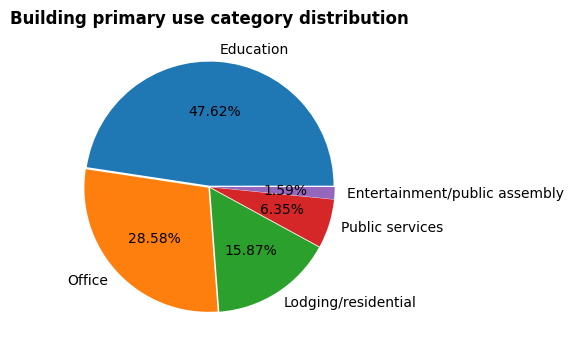

In [22]:
fig, ax = plt.subplots(ncols=1, figsize=(5, 4))
# Pie chart
building_use_counts = df_cleaned['Building Use'].value_counts()
building_use_counts.plot(kind="pie", autopct="%.2f%%", ax=ax,ylabel="",explode=([0.01] * len(building_use_counts)))
ax.set_title("Building primary use category distribution", fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()

From the figure shown above, it can be seen that the use of building for Education dominates with 47.62% of the total building in area site 1, followed by office (28.58%), lodging/residential (15.87%), public service (6.35%), and lastly the least building use in area site 1 is for entertainment/public assembly. This shows that most building in area site 1 is is for education and office, accounting for more than 70% of the total building use. Therefore, it is safe to say that area site 1 is not in a predominantly residential area and more likely the area is used for a central business district (CBD) that is characterized by a high concentration of office and educational fascilities. This type of area is contributing significantly to the local economy and community life.

C. EDA: Effect of Building Use to Energy (Electricity) Usage

Next, we will examine whether building area has any effect on meter readings for meter type 0 (electricity) across each building use category.

In [23]:
df_cleaned['Building Area (sqft)'].describe()

count     20000.000000
mean      65797.413500
std       40631.716567
min        5374.000000
25%       32206.000000
50%       57673.000000
75%       91149.000000
max      174601.000000
Name: Building Area (sqft), dtype: float64

According to the data above, the minimum building area is around 5374 sqft, while the maximum building area is around 174601 sqft. Therefore, we would find out if the min, 25% percentile, 50% percentile, 75% percentile, and 100% of the building area in each building use have any difference in their meter readings. This would give us insight into how much the building area affects the meter reading for energy usage (electricity) in these buildings.

In [24]:
#define percentile boundaries based on your stated min/max
area_bins = [5374,
             df_cleaned['Building Area (sqft)'].quantile(0.25),
             df_cleaned['Building Area (sqft)'].quantile(0.50),
             df_cleaned['Building Area (sqft)'].quantile(0.75),
             174601]

area_labels = ['Min-25%', '25%-50%', '50%-75%', '75%-Max']

#create area percentile groups
df_cleaned['area_percentile'] = pd.cut(
    df_cleaned['Building Area (sqft)'],
    bins=area_bins,
    labels=area_labels,
    include_lowest=True
)

#filter electricity only (meter == 0) AND drop NaN meter readings
df_electricity = df_cleaned[
    (df_cleaned['Meter Type'] == 0) &
    (df_cleaned['Meter Reading (kWh)'].notna()) &
    (df_cleaned['area_percentile'].notna())       # exclude unclassified area rows
]

#group by Building Use and area_percentile, get mean meter_reading
area_percentile_analysis = (
    df_electricity
    .groupby(['Building Use', 'area_percentile'], observed=True)['Meter Reading (kWh)']
    .mean()
    .reset_index()
    .rename(columns={'Meter Reading (kWh)': 'avg_meter_reading'})
    .round(2)
)

#pivot for easier comparison
pivot_table = area_percentile_analysis.pivot(
    index='Building Use',
    columns='area_percentile',
    values='avg_meter_reading'
)

print(pivot_table)

area_percentile                Min-25%  25%-50%  50%-75%  75%-Max
Building Use                                                     
Education                       115.18   137.11   281.40   462.55
Entertainment/public assembly      NaN      NaN    47.78      NaN
Lodging/residential              21.92    50.72    62.63    93.51
Office                           25.63    75.27   224.46   200.79
Public services                    NaN    80.06      NaN   134.80


As seen from the above data, we could clearly see that the increase of electricity usage is the larger the area of the building. However, the rate of increase differs significantly by use type. The visualization below would give a clear picture of the data above.

<Figure size 1400x700 with 0 Axes>

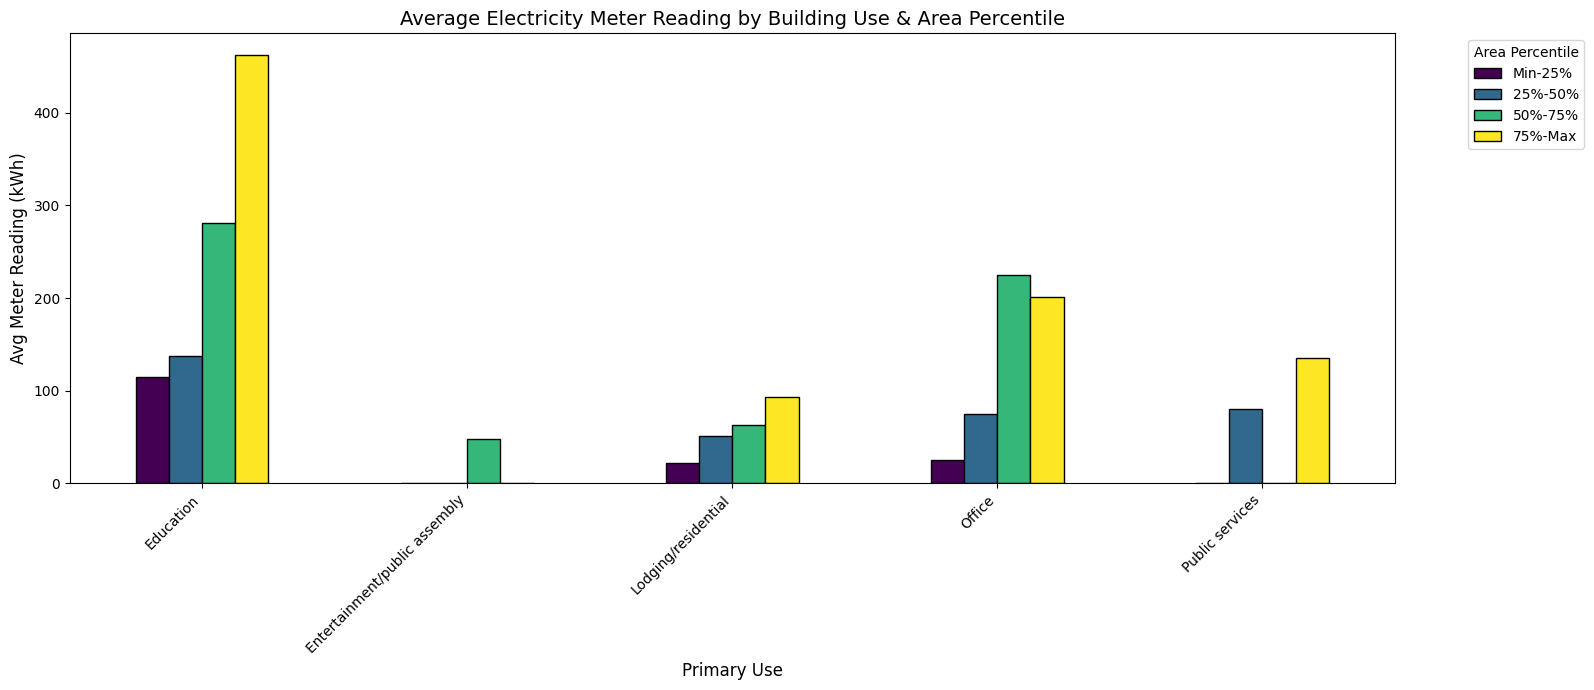

In [25]:
plt.figure(figsize=(14, 7))
pivot_table.plot(kind='bar', figsize=(16, 7), colormap='viridis', edgecolor='black')

plt.title('Average Electricity Meter Reading by Building Use & Area Percentile', fontsize=14)
plt.xlabel('Primary Use', fontsize=12)
plt.ylabel('Avg Meter Reading (kWh)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Area Percentile', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

It can be seen that from each of the building uses, that generally would increase as the building area gets larger, like in building for Education and buildings for Lodging/residential. The building for education shows the steepest difference between min-25% to 75%-max, with around 4x consumption in the latter quantile. The education building might drive the electricity usage up due to high-powered usage like labs, lecture halls, HVAC systems, etc.


For the lodging/residential area, it has the lowest absolute average electricity usage (kWh), but the increase of electricity over the building area is the most gradual and consistent across all percentiles. This suggests that this building area is a reliable predictor for electricity usage.


However, as for the office, it can be seen that when reaching a certain point, the average electricity usage, as observed, there is a decrese of electricity usage from the building area at 50%-75% quantile and 75%-max quantile. This would mean that after the building area reaches above 91149 sqft (quantile 75%), the electricity usage begins to decrease. Some of the possible explanations would be that not area in the building get used often, therefore the electricity usage is minimal in some areas with rare/occasional use. Furthermore, the bigger the building, usually their energy management and building energy label would be much more efficient and environmentally friendly system (i.e., low-watt office appliances, heat exchange system installed, green building certificate). Therefore, it might also explain why there is a decrease after a certain point in sqft area. For building Entertaintment/public assemly, it can be observed that there are some missing.


As for entertainment and public services buildings, the data shows that it is insufficient oto deduce the difference between each quantile, therefore we cannot draw a conclusion. These gaps might be due to very few buildings of this type falling into each area percentile.

D. EDA: Effect of Building Age (Year Built) to Energy Usage (Meter Reading (kWh))

In [26]:
df_cleaned['Year Built'].agg(['max', 'min'])

max    2007
min    1900
Name: Year Built, dtype: int64

The oldest building is built in year 1900, and the newset building is built in year 2007. Therefore, we can analyze the energy data based on the era category, such as Pre-Energy Code (1900-1980) and Post-Energy Code (1981–2007). These categories is chosen because during the Pre-Energy Code, there is no formal energy standard in the building, usually have the poorest insulation and an inefficient system. As for Post-Energy Code , this era is where the first energy regulation is being implemented (ASHRAE 90-1975) triggered by the energy crisis, and where the HVAC system is introduced with better insulation and an efficient system.  

In [27]:
"""
To generally see the general value (min,max,mean,meadian,std,Q1,Q2,Q3) of meter readings difference between building made before year 1981 and after year 1980.
This is useful to determine if the building was built before year 1981 has higher meter reading compared to building built after year 1980.
"""
built_before_1981 = df_cleaned[df_cleaned['Year Built'] < 1981]['Meter Reading (kWh)'].describe().round(2)
built_after_1980 = df_cleaned[df_cleaned['Year Built'] > 1980]['Meter Reading (kWh)'].describe().round(2)

print(f"Building built before 1981 (meter reading, kWh): {built_before_1981}")
print()
print(f"Building built after 1980 (meter reading, kWh): {built_after_1980}")

Building built before 1981 (meter reading, kWh): count    10723.00
mean       184.87
std        204.42
min          0.00
25%         37.90
50%        100.00
75%        281.55
max       1376.00
Name: Meter Reading (kWh), dtype: float64

Building built after 1980 (meter reading, kWh): count    4217.00
mean      174.55
std       156.92
min         0.00
25%        52.60
50%       112.60
75%       268.50
max       947.70
Name: Meter Reading (kWh), dtype: float64


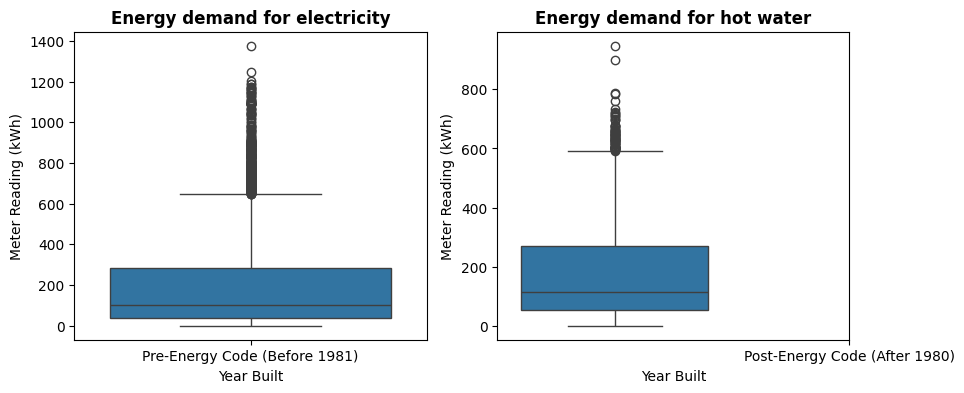

In [28]:
"""
Create multiple box plots to compare distributions across categories
- x='Year': creates separate box plot for each category
- y='Price': the values to show distribution for
Useful for comparing distributions between groups
"""
energy_before_1981 = df_cleaned[df_cleaned['Year Built'] < 1981]['Meter Reading (kWh)']
energy_after_1980 = df_cleaned[df_cleaned['Year Built'] > 1980]['Meter Reading (kWh)']

fig, ax = plt.subplots(ncols=2,figsize=(10,4))

sns.boxplot(data=energy_before_1981, ax=ax[0])
ax[0].set_xticks([0])
ax[0].set_xticklabels(['Pre-Energy Code (Before 1981)'])
ax[0].set_xlabel("Year Built")
ax[0].set_ylabel("Meter Reading (kWh)")
ax[0].set_title("Energy demand for electricity", fontsize=12, fontweight='bold')

sns.boxplot(data=energy_after_1980, ax=ax[1])
ax[1].set_xticks([1])
ax[1].set_xticklabels(['Post-Energy Code (After 1980)'], ha='center')
ax[1].set_xlabel("Year Built")
ax[1].set_ylabel("Meter Reading (kWh)")
ax[1].set_title("Energy demand for hot water", fontsize=12, fontweight='bold')
plt.show()

From the data, it can be seen that a building built before the year 1981 has a higher average energy demand (meter reading) of 184.87 compared to the average energy demand (meter reading) of a building built after the year 1980 of 174.55. However, we need to make sure that the difference is statistically significant enough. To do this, we need to do a correlation test using Spearman between the two category. The Spearman method is chosen because the relation between data can be monotonic or not linear, but still moving in one direction. The method can be used for data with outliers, and this method is not sensitive towards outliers, therefore it is suitable for our data with a lot of outliers. However, we need to make sure that the difference is statistically significant enough. To do this, we need to do *two-sample test: two-sided* using 2 independent sample, between a building that was built before year 1981 and after year 1980. The *two-sided: two-test* is chosen because we only need to know if there is a difference of meter reading (kWh)/energy usage between a building that was built before year 1981 and after year 1980 without considering the direction of the effect. The hypothesis is as follows:


H0: There is no significant difference in meter readings/energy usage between a building that was built before the year 1981 and after the year 1980


H1: There is a significant difference in meter readings/energy usage between a building that was built before the year 1981 and after the year 1980


In this case, if H0 is being rejected, then there is a significant difference in meter readings/energy usage between a building that was built before year 1981 and after the year 1980. On the other hand, if H0 is being accepted, then there is no significant difference in meter readings/energy usage between a building that was built before the year 1981 and after the year 1980, which in this case means that another factor is at play for the insignificant difference (i.e., building area, building use, etc). Therefore, we need to do inferential statistic analysis to find out if when the building is built affects the energy demand/usage (kWh).

In [29]:
before_1981 = df_cleaned[df_cleaned['Year Built'] < 1981]
after_1980 = df_cleaned[df_cleaned['Year Built'] > 1980]

In [30]:
t_stat, p_val = stats.ttest_ind(before_1981["Meter Reading (kWh)"], after_1980["Meter Reading (kWh)"])
print("T-Statistik:", t_stat)
print("P-value:", p_val)

T-Statistik: 2.95411224971642
P-value: 0.003140587644327883


The *p-value:0.0031 is lower than 0.05*, so it could be concluded that *the null hyphothesis is rejected*. This means that the energy usage/meter reading (kWh) between a building built before year 1981 and after year 1980 has a significant difference. This means that a building built before the year 1981 has a higher energy demand/usage (meter reading) compared to the energy demand/usage (meter reading) of a building built after the year 1980. Some of the reasons why this might be the case is because, a old buildings built before the year 1981 generally have poor insulation, an inefficient system, and no energy regulation during that time to regulate the energy system. This could explain why the energy usage/meter readings in buildings built during the pre-energy code era might be higher than those of more recently built ones (post-energy code era).

E. EDA: Effect of Meter Type to Energy Usage (Meter Reading (kWh))

Lastly, we want to examine whether there is a significant difference in meter readings (energy usage) between buildings that use electricity and those that use hot water.

In [31]:
"""
To generally see the general value (min,max,mean,meadian,std,Q1,Q2,Q3) difference between house made before year 2000 and after year 2000.
This is useful to determine if the house build before year 2000 is cheaper than the house built after year 2000.
"""
energy_electricity = df_cleaned[df_cleaned['Meter Type'] == 0]['Meter Reading (kWh)'].describe().round(2)
energy_hot_water = df_cleaned[df_cleaned['Meter Type'] == 3]['Meter Reading (kWh)'].describe().round(2)

print(f"Electricity: {energy_electricity}")
print()
print(f"Hot Water: {energy_hot_water}")

Electricity: count    16231.00
mean       161.97
std        182.31
min          0.00
25%         36.50
50%         87.90
75%        225.60
max       1376.00
Name: Meter Reading (kWh), dtype: float64

Hot Water: count    3769.00
mean       91.50
std       148.73
min         0.00
25%         0.00
50%        30.00
75%       100.00
max      1791.10
Name: Meter Reading (kWh), dtype: float64


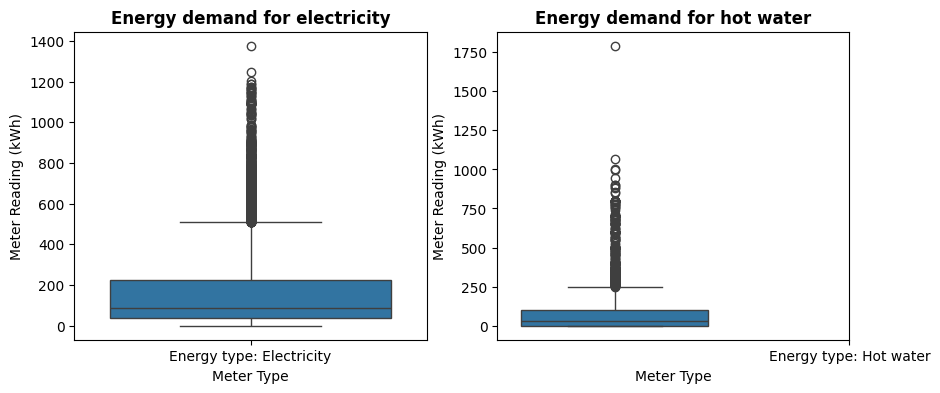

In [32]:
"""
Create multiple box plots to compare distributions across categories
- x='Year': creates separate box plot for each category
- y='Price': the values to show distribution for
Useful for comparing distributions between groups
"""
energy_electricity = df_cleaned[df_cleaned['Meter Type'] == 0]['Meter Reading (kWh)']
energy_hot_water = df_cleaned[df_cleaned['Meter Type'] == 3]['Meter Reading (kWh)']

fig, ax = plt.subplots(ncols=2,figsize=(10,4))

sns.boxplot(data=energy_electricity, ax=ax[0])
ax[0].set_xticks([0])
ax[0].set_xticklabels(['Energy type: Electricity'])
ax[0].set_xlabel("Meter Type")
ax[0].set_ylabel("Meter Reading (kWh)")
ax[0].set_title("Energy demand for electricity", fontsize=12, fontweight='bold')

sns.boxplot(data=energy_hot_water, ax=ax[1])
ax[1].set_xticks([1])
ax[1].set_xticklabels(['Energy type: Hot water'])
ax[1].set_xlabel("Meter Type")
ax[1].set_ylabel("Meter Reading (kWh)")
ax[1].set_title("Energy demand for hot water", fontsize=12, fontweight='bold')
plt.show()

From the data, it can be seen that the energy demand for electricity has a higher average energy demand (meter reading) of 161.97 compared to the energy demand for hot water, with an average energy demand (meter reading) of 91.50. However, we need to make sure that the difference is statistically significant enough. To do this, we need to do a correlation test using Spearman, between the energy demand for electricity and the energy demand for hot water. The Spearman method is chosen because the relation between data can be monotonic or not linear, but still moving in one direction. The method can be used for data with outliers, and this method is not sensitive towards outliers, therefore it is suitable for our data with a lot of outliers. However, we need to make sure that the difference is statistically significant enough. To do this, we need to do *two-sample test: two-sided* using 2 independent sample, between building that use electricity and building that use hot water as the demand/meter type. The *two-sided: two-test* is chosen because we only need to know if there is a difference of house price between building that use electricity and building that use hot water as the demand/meter type without considering the direction of the effect. The hypothesis is as follows:


H0: There is no significant difference in energy usage/meter reading between buildings that use electricity and buildings that use hot water as the demand/meter type

H1: There is a significant difference in energy usage/meter reading between buildings that use electricity and buildings that use hot water as the demand/meter type


In this case, if H0 is being rejected, then there is a significant difference between building that use electricity and building that use hot water as the demand/meter type. On the other hand, if H0 is being accepted, then there is no significant difference between buildings that use electricity and buildings that use hot water as the demand/meter type, which in this case means that another factor is at play for the insignificant difference (i.e., building area, building use, etc). Therefore, we need to do inferential statistic analysis to find out if the energy demand type (electricity and hot water) affects the energy demand/usage (kWh).

In [33]:
# Filter data by year
energy_electricity_data = df_cleaned[df_cleaned['Meter Type'] == 0]
energy_hot_water_data = df_cleaned[df_cleaned['Meter Type'] == 3]

In [34]:
t_stat, p_val = stats.ttest_ind(energy_electricity_data['Meter Reading (kWh)'], energy_hot_water_data['Meter Reading (kWh)'])
print("T-Statistik:", t_stat)
print("P-value:", p_val)

T-Statistik: 22.08469194358913
P-value: 8.376906964393825e-107


The *p-value: 8.37 810^-107 is lower than 0.05*, so it could be concluded that *the null hyphothesis is rejected*. This means that the energy usage/demand between building that use electricity and building that use hot water as the demand/meter type has a significant difference. This means that a building that use electricity as energy demand/meter type has a higher meter reading/energy usage (kWh) compared to a building that use electricity as energy demand/meter type. Some of the reasons why this might be the case is because the electricity energy demand support boarder range of use compared to the hot water energy demand. Buildings that use electricity as their primary energy source often power not just heating, but also cooling (air conditioning), lighting, appliances, plug loads, and ventilation systems. This results in a much higher cumulative energy demand compared to buildings that rely solely on hot water (typically used only for space heating and domestic hot water). Furthermore, when electricity is used for heating purposes, the electric resistance systems are generally less efficient compared to hot water-based heating systems, therefore resulting in more energy (kWh) being consumed. Moreover, electrically-metered buildings often tend to have a constant baseline load (i.e., servers, security system, elevators, heating system, refrigeration, etc) so making it have a constant 24/7 baseload energy consumption. Lastly, electricity-based energy often runs throughout all seasons, with electricity-based meter buildings facing high demand in both summer (cooling) and winter (heating), creating a year-round high energy profile, whereas hot water systems primarily see demand spikes only in colder months.  All of these contribute to an overall higher energy (kWh) consumption.  

Finally, we will examine the correlation between each column to gain a general understanding of which columns may be relevant for feature engineering.

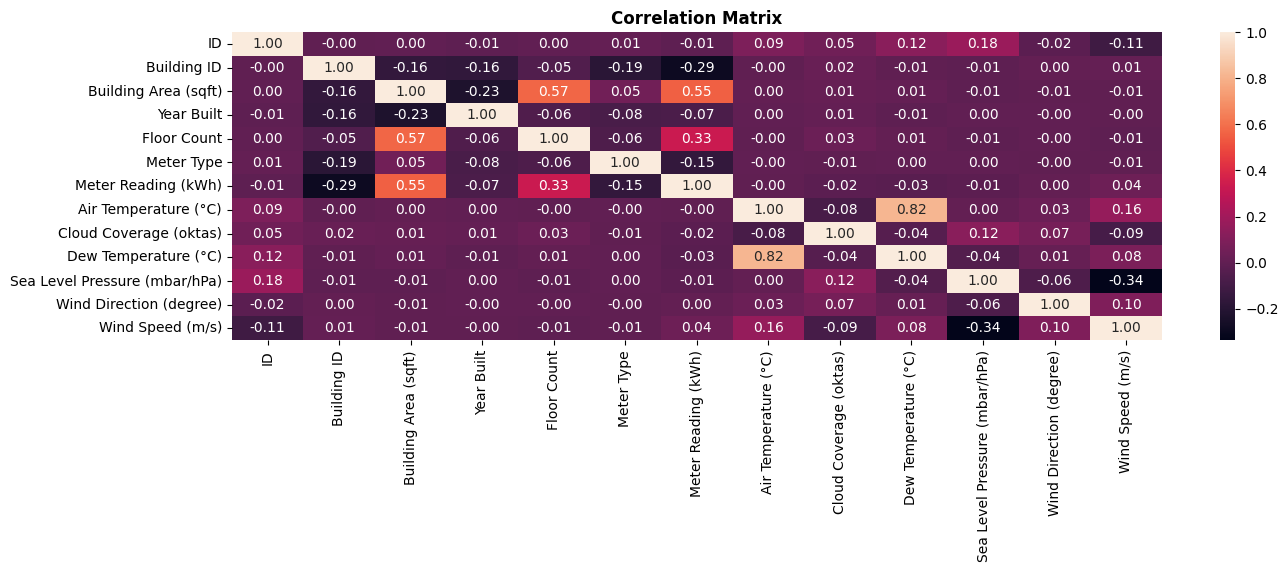

In [35]:
"""
Create a heatmap to visualize correlation matrix
- annot=True: displays correlation values in each cell
Heatmaps make it easy to spot strong relationships between variables
"""

plt.figure(figsize=(15,4))
sns.heatmap(df_cleaned[['ID', 'Building ID', 'Building Use', 'Building Area (sqft)',
       'Year Built', 'Floor Count', 'Meter Type', 'Time Stamp',
       'Meter Reading (kWh)', 'Air Temperature (°C)', 'Cloud Coverage (oktas)',
       'Dew Temperature (°C)', 'Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)',
       'Wind Speed (m/s)']].corr(numeric_only=True), annot=True, fmt ='.2f')
plt.title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.show()

From the heatmap above, we have the general idea that energy demand/meter readings (kWh) correlates more strongly with floor counts (0.33) and building area (0.55). This makes sense because the larger the building area and the more floors there are to cover, the greater the demand on electrical systems, this also includes demands like lighting, heating/cooling, and other building services. This condition will drive the overall energy consumption higher. However, we need to prove this correlation further during our feature engineering. This heatmap only serves as a pre-overview of what to expect in the feature engineering. Below are scatter plots visualizing the correlation between meter readings and building area, floor count. It can be seen that both show positive correlation, further supporting the findings above.


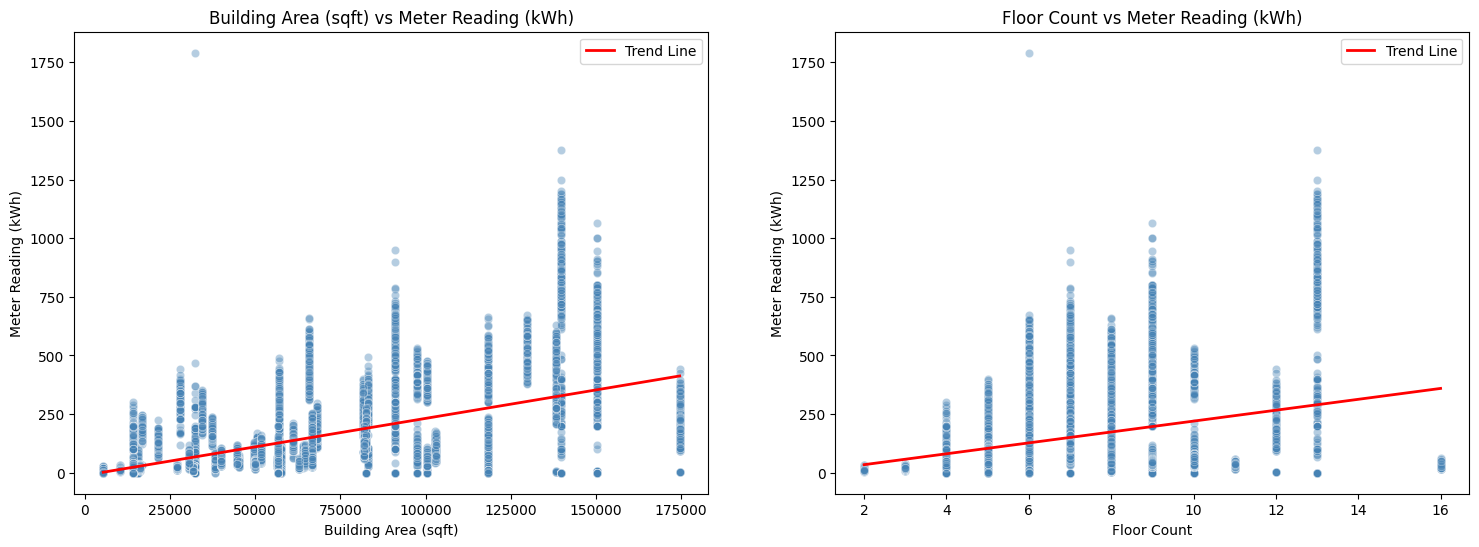

In [36]:
#scatter plot to further show correlation between meter readings vs building areaa nd floor count
fig, axes = plt.subplots(ncols=2, figsize=(18, 6))

# ── Plot 1: Building Area vs Meter Reading ─────────────────────
axes[0].scatter(df_cleaned['Building Area (sqft)'], df_cleaned['Meter Reading (kWh)'], alpha=0.4, color='steelblue', edgecolors='w', linewidth=0.5)
axes[0].set_title('Building Area (sqft) vs Meter Reading (kWh)')
axes[0].set_xlabel('Building Area (sqft)')
axes[0].set_ylabel('Meter Reading (kWh)')

m, b = np.polyfit(df_cleaned['Building Area (sqft)'], df_cleaned['Meter Reading (kWh)'], 1)
axes[0].plot(sorted(df_cleaned['Building Area (sqft)']),
             [m*x + b for x in sorted(df_cleaned['Building Area (sqft)'])],
             color='red', linewidth=2, label='Trend Line')
axes[0].legend()

# ── Plot 2: Floor Count vs Meter Reading ───────────────────────
axes[1].scatter(df_cleaned['Floor Count'], df_cleaned['Meter Reading (kWh)'], alpha=0.4, color='steelblue', edgecolors='w', linewidth=0.5)
axes[1].set_title('Floor Count vs Meter Reading (kWh)')
axes[1].set_xlabel('Floor Count')
axes[1].set_ylabel('Meter Reading (kWh)')

m, b = np.polyfit(df_cleaned['Floor Count'], df_cleaned['Meter Reading (kWh)'], 1)
axes[1].plot(sorted(df_cleaned['Floor Count']),
             [m*x + b for x in sorted(df_cleaned['Floor Count'])],
             color='red', linewidth=2, label='Trend Line')
axes[1].legend()


V. Feature Engineering

First, we need to make a copy of the cleaned DataFrame in order to make a df for doing feature engineering.

In [37]:
#copy the cleaned data to be used in FE
df_fe = df_uncleaned.copy()
df_fe.head()

,ID,Building ID,Site ID,Building Use,Building Area (sqft),Year Built,Floor Count,Meter Type,Time Stamp,Meter Reading (kWh),Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Precipitation Depth (mm/hr),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s)
0,13214777,126,1,Education,21539,2004,5,0,2016-04-28 15:00:00,120.6,10.5,NaN,0.7,NaN,1012.3,220.0,8.2
1,13284987,125,1,Education,16802,1995,6,0,2016-05-01 04:00:00,141.3,2.7,0.0,2.0,NaN,1028.1,250.0,1.5
2,6042358,112,1,Education,32206,<NA>,6,0,2016-08-10 04:00:00,0.0,10.9,NaN,7.8,NaN,1024.7,290.0,3.1
3,15884458,107,1,Education,97532,2005,10,0,2016-08-02 07:00:00,84.3,17.5,NaN,16.3,NaN,1009.6,220.0,5.1
4,14364089,122,1,Education,83043,1991,6,0,2016-06-08 20:00:00,254.8,20.5,NaN,17.9,NaN,1023.1,10.0,1.5


In [38]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   ID                             20000 non-null  int64         
 1   Building ID                    20000 non-null  int64         
 2   Site ID                        20000 non-null  int64         
 3   Building Use                   20000 non-null  object        
 4   Building Area (sqft)           20000 non-null  int64         
 5   Year Built                     14940 non-null  Int64         
 6   Floor Count                    20000 non-null  int32         
 7   Meter Type                     20000 non-null  int64         
 8   Time Stamp                     20000 non-null  datetime64[ns]
 9   Meter Reading (kWh)            20000 non-null  float64       
 10  Air Temperature (°C)           19996 non-null  float64       
 11  Cloud Coverage 

a. Split X and Y

In [39]:
df_fe.columns

Index(['ID', 'Building ID', 'Site ID', 'Building Use', 'Building Area (sqft)',
       'Year Built', 'Floor Count', 'Meter Type', 'Time Stamp',
       'Meter Reading (kWh)', 'Air Temperature (°C)', 'Cloud Coverage (oktas)',
       'Dew Temperature (°C)', 'Precipitation Depth (mm/hr)',
       'Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)',
       'Wind Speed (m/s)'],
      dtype='object')

First, we need to separate the feature columns (X) from the target column (y) for the machine learning model. The 'Meter Reading (kWh)' column will be used as the target (y) because this is what the model aims to predict. The remaining columns will serve as features (X), except for column 'ID', 'Building ID', and 'Site ID', as these only serve as building information/identifiers and do not contribute to meter readings. Adittionally, the 'Precipitation Depth (mm/hr)' column will also be dropped from the features as it contains entirely null values. This is because precipitation depth is only recorded during rainfall, and since there is no recorded data throughout the column, it will be dropped. Lastly, the 'Timestamp' column contains information about when the meter reading was taken. The only useful information from this column is the time of day, rather than the date itself. The time information may be useful for observing energy demand patterns during morning, afternoon, and evening periods, and will therefore be converted into a categorical column.

<Axes: xlabel='Meter Reading (kWh)', ylabel='Frequency'>

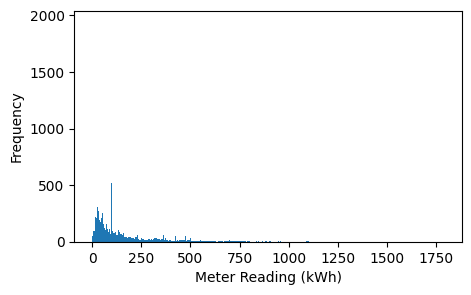

In [40]:
#Checking Price data to create y
fig, ax = plt.subplots(ncols=1, figsize=(5,3))
df_fe['Meter Reading (kWh)'].plot(kind="hist", bins=1000, ax=ax, xlabel='Meter Reading (kWh)')

As seen from above, the 'Meter Reading (kWh)' data is slightly positively skewed. However, some of the models that will be tested like Decision Tree Regressor, Random Forest, and Gradient Boosting are robust against skewness and outliers so there is no need to normalized. As for KNN and SVM, they can still tolerate skewness if the proportion of outliers is relatively low (< 5%).

In [41]:
y = df_fe['Meter Reading (kWh)']
y.head()


0    120.6
1    141.3
2      0.0
3     84.3
4    254.8
Name: Meter Reading (kWh), dtype: float64

Next, we need to drop 'Meter Reading (kWh)' from the X columns as it is already assigned to y. We will also drop 'ID', 'Building ID', 'Site ID', and 'Precipitation Depth (mm/hr)'.

In [42]:
# creating X
X = df_fe.drop(columns=['Meter Reading (kWh)', 'ID', 'Building ID', 'Site ID', 'Precipitation Depth (mm/hr)'],axis=1) # All the possible features

#Check the X
X.head()

,Building Use,Building Area (sqft),Year Built,Floor Count,Meter Type,Time Stamp,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s)
0,Education,21539,2004,5,0,2016-04-28 15:00:00,10.5,NaN,0.7,1012.3,220.0,8.2
1,Education,16802,1995,6,0,2016-05-01 04:00:00,2.7,0.0,2.0,1028.1,250.0,1.5
2,Education,32206,<NA>,6,0,2016-08-10 04:00:00,10.9,NaN,7.8,1024.7,290.0,3.1
3,Education,97532,2005,10,0,2016-08-02 07:00:00,17.5,NaN,16.3,1009.6,220.0,5.1
4,Education,83043,1991,6,0,2016-06-08 20:00:00,20.5,NaN,17.9,1023.1,10.0,1.5


b. Split numerical and categorical column

In [43]:
X.columns

Index(['Building Use', 'Building Area (sqft)', 'Year Built', 'Floor Count',
       'Meter Type', 'Time Stamp', 'Air Temperature (°C)',
       'Cloud Coverage (oktas)', 'Dew Temperature (°C)',
       'Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)',
       'Wind Speed (m/s)'],
      dtype='object')

In [44]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Building Use                   20000 non-null  object        
 1   Building Area (sqft)           20000 non-null  int64         
 2   Year Built                     14940 non-null  Int64         
 3   Floor Count                    20000 non-null  int32         
 4   Meter Type                     20000 non-null  int64         
 5   Time Stamp                     20000 non-null  datetime64[ns]
 6   Air Temperature (°C)           19996 non-null  float64       
 7   Cloud Coverage (oktas)         3960 non-null   float64       
 8   Dew Temperature (°C)           19996 non-null  float64       
 9   Sea Level Pressure (mbar/hPa)  19879 non-null  float64       
 10  Wind Direction (degree)        19994 non-null  float64       
 11  Wind Speed (m/s

In [45]:
X.head()

,Building Use,Building Area (sqft),Year Built,Floor Count,Meter Type,Time Stamp,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s)
0,Education,21539,2004,5,0,2016-04-28 15:00:00,10.5,NaN,0.7,1012.3,220.0,8.2
1,Education,16802,1995,6,0,2016-05-01 04:00:00,2.7,0.0,2.0,1028.1,250.0,1.5
2,Education,32206,<NA>,6,0,2016-08-10 04:00:00,10.9,NaN,7.8,1024.7,290.0,3.1
3,Education,97532,2005,10,0,2016-08-02 07:00:00,17.5,NaN,16.3,1009.6,220.0,5.1
4,Education,83043,1991,6,0,2016-06-08 20:00:00,20.5,NaN,17.9,1023.1,10.0,1.5


From the information above, the numerical columns are 'Timestamp', 'Year Built', 'Building Area (sqft)', 'Floor Count', 'Air Temperature (°C)', 'Cloud Coverage (oktas)', 'Dew Temperature (°C)', 'Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)', and 'Wind Speed (m/s)'.

The categorical columns are 'Meter Type' and 'Building Use'.

In [46]:
# Saving columns with numerical data in new variable
num_col = ['Building Area (sqft)', 'Floor Count', 'Air Temperature (°C)','Cloud Coverage (oktas)', 'Dew Temperature (°C)','Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)', 'Wind Speed (m/s)']

#Saving columns with categorical data in new variable
cat_col = ['Meter Type', 'Building Use', 'Time Stamp', 'Year Built']

For the 'Meter Type' column, even though it is stored as a numerical column, its values represent categories, such as 0 represents electricity and 3 represents hot water. Therefore, these numerical values will be converted into string labels.

For the 'Year Built' column, while it is also numerical, however we can categorize it based on construction era, specifically, the pre-energy code era (before 1981) and the post-energy code era (after 1980), resulting in 2 categories.

For the 'Timestamp' column, only the time data will be extracted and categorized into three categories, such as Morning/Day (06:00 – 13:59), representing the start of work and school hours; Afternoon/Evening (14:00 – 21:59), representing the period when peak activity winds down; and Night (22:00 – 05:59), representing low activity and minimal energy usage.

c. Cardinality check for categorical columns

In [47]:
# Looping to see how many unique value and the unique label in each category

for i in cat_col:
    print(f"{i} {X[i].unique()}")
    print(f"Number of unique column: {i} --> {X[i].nunique()}")
    print()

Meter Type [0 3]
Number of unique column: Meter Type --> 2

Building Use ['Education' 'Entertainment/public assembly' 'Lodging/residential'
 'Office' 'Public services']
Number of unique column: Building Use --> 5

Time Stamp <DatetimeArray>
['2016-04-28 15:00:00', '2016-05-01 04:00:00', '2016-08-10 04:00:00',
 '2016-08-02 07:00:00', '2016-06-08 20:00:00', '2016-10-31 03:00:00',
 '2016-10-21 11:00:00', '2016-05-16 12:00:00', '2016-07-24 10:00:00',
 '2016-06-06 23:00:00',
 ...
 '2016-12-10 05:00:00', '2016-06-19 02:00:00', '2016-11-22 10:00:00',
 '2016-12-15 07:00:00', '2016-05-05 18:00:00', '2016-09-30 22:00:00',
 '2016-05-02 07:00:00', '2016-07-25 13:00:00', '2016-04-17 07:00:00',
 '2016-06-18 04:00:00']
Length: 7927, dtype: datetime64[ns]
Number of unique column: Time Stamp --> 7927

Year Built <IntegerArray>
[2004, 1995, <NA>, 2005, 1991, 1958, 1960, 2006, 1976, 1968, 2007, 1906, 1953,
 1909, 1900, 1913, 1989, 1967, 1956, 1998, 1930, 1907, 1977, 1919, 1965, 1997,
 1970, 1955]
Length:

As seen from above, 'Meter Type' and 'Building Use' have low cardinality (< 5), so there is no need to handle cardinality for these columns. However, the 'Timestamp' column has high cardinality and contains date information that is not needed. Therefore, only the time data will be extracted and categorized into the 3 categories discussed above.

In [48]:
#to ensure Time Stamp is datetime
X['Time Stamp'] = pd.to_datetime(X['Time Stamp'])

#to extract time only
X['Time'] = X['Time Stamp'].dt.time

#to categorize based on hour
def categorize_time(hour):
    if 6 <= hour < 14:
        return 'Morning/Day'
    elif 14 <= hour < 22:
        return 'Afternoon/Evening'
    else:
        return 'Night'

X['Time Category'] = X['Time Stamp'].dt.hour.apply(categorize_time)

print(X[['Time Stamp', 'Time', 'Time Category']].head())

           Time Stamp      Time      Time Category
0 2016-04-28 15:00:00  15:00:00  Afternoon/Evening
1 2016-05-01 04:00:00  04:00:00              Night
2 2016-08-10 04:00:00  04:00:00              Night
3 2016-08-02 07:00:00  07:00:00        Morning/Day
4 2016-06-08 20:00:00  20:00:00  Afternoon/Evening


Now, we move on to the Era Category.

In [49]:
#to categorize based on era
def categorize_era(year):
    if year < 1981:
        return 'Pre-Energy Code Era (before 1981)'
    elif year > 1980:
        return 'Post-Energy Code Era (after 1980)'

X['Era Category'] = X['Year Built'].apply(categorize_era)

print(X[['Era Category', 'Year Built']].head())

                        Era Category  Year Built
0  Post-Energy Code Era (after 1980)        2004
1  Post-Energy Code Era (after 1980)        1995
2                               None        <NA>
3  Post-Energy Code Era (after 1980)        2005
4  Post-Energy Code Era (after 1980)        1991


Now, we need to categorize the meter type into categorical label.

In [50]:
X['Meter Type Category'] = X['Meter Type'].replace({
    0: 'Electricity',
    3: 'Hot Water'
})

In [51]:
X.head()

,Building Use,Building Area (sqft),Year Built,Floor Count,Meter Type,Time Stamp,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s),Time,Time Category,Era Category,Meter Type Category
0,Education,21539,2004,5,0,2016-04-28 15:00:00,10.5,NaN,0.7,1012.3,220.0,8.2,15:00:00,Afternoon/Evening,Post-Energy Code Era (after 1980),Electricity
1,Education,16802,1995,6,0,2016-05-01 04:00:00,2.7,0.0,2.0,1028.1,250.0,1.5,04:00:00,Night,Post-Energy Code Era (after 1980),Electricity
2,Education,32206,<NA>,6,0,2016-08-10 04:00:00,10.9,NaN,7.8,1024.7,290.0,3.1,04:00:00,Night,None,Electricity
3,Education,97532,2005,10,0,2016-08-02 07:00:00,17.5,NaN,16.3,1009.6,220.0,5.1,07:00:00,Morning/Day,Post-Energy Code Era (after 1980),Electricity
4,Education,83043,1991,6,0,2016-06-08 20:00:00,20.5,NaN,17.9,1023.1,10.0,1.5,20:00:00,Afternoon/Evening,Post-Energy Code Era (after 1980),Electricity


In [52]:
X.columns

Index(['Building Use', 'Building Area (sqft)', 'Year Built', 'Floor Count',
       'Meter Type', 'Time Stamp', 'Air Temperature (°C)',
       'Cloud Coverage (oktas)', 'Dew Temperature (°C)',
       'Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)',
       'Wind Speed (m/s)', 'Time', 'Time Category', 'Era Category',
       'Meter Type Category'],
      dtype='object')

Therefore, from the features above, the only categorical columns needed are 'Time Category', 'Building Use', 'Era Category', and 'Meter Type Category'. The columns 'Meter Type', 'Timestamp', 'Year Built', and 'Time' will be dropped as they are already represented in the newly created columns.

In [53]:
#Create new category column with reduced cardinality features
cat_col_new=['Building Use', 'Time Category', 'Era Category',
       'Meter Type Category']

X_new=X.drop(['Meter Type', 'Time Stamp', 'Time', 'Year Built'],axis=1)
X_new.head()

,Building Use,Building Area (sqft),Floor Count,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s),Time Category,Era Category,Meter Type Category
0,Education,21539,5,10.5,NaN,0.7,1012.3,220.0,8.2,Afternoon/Evening,Post-Energy Code Era (after 1980),Electricity
1,Education,16802,6,2.7,0.0,2.0,1028.1,250.0,1.5,Night,Post-Energy Code Era (after 1980),Electricity
2,Education,32206,6,10.9,NaN,7.8,1024.7,290.0,3.1,Night,None,Electricity
3,Education,97532,10,17.5,NaN,16.3,1009.6,220.0,5.1,Morning/Day,Post-Energy Code Era (after 1980),Electricity
4,Education,83043,6,20.5,NaN,17.9,1023.1,10.0,1.5,Afternoon/Evening,Post-Energy Code Era (after 1980),Electricity


As seen from the table above, the updated categorical columns now consist of 'Time Category', 'Building Use', and 'Meter Type Category'.

d. Missing value handling

In [54]:
X_new.isnull().sum()

Building Use                         0
Building Area (sqft)                 0
Floor Count                          0
Air Temperature (°C)                 4
Cloud Coverage (oktas)           16040
Dew Temperature (°C)                 4
Sea Level Pressure (mbar/hPa)      121
Wind Direction (degree)              6
Wind Speed (m/s)                     0
Time Category                        0
Era Category                      5060
Meter Type Category                  0
dtype: int64

It can be seen that from the train-set there are several columns with null value, such as Era Category (5060), Air Temperature (°C) (4), Cloud Coverage (oktas) (16040), Dew Temperature (°C)(4), Sea Level Pressure (mbar/hPa) (121), and Wind Direction (degree) (6). Therefore, missing value handling is required for the X-train set.

In [55]:
y.isnull().sum()

0

However, there are no missing values in y ; therefore, no missing value handling is required.

In handling numerical missing values, we first need to assess the proportion of missing data. In this case, there are 5 columns containing missing values.

In [56]:
X_new.columns

Index(['Building Use', 'Building Area (sqft)', 'Floor Count',
       'Air Temperature (°C)', 'Cloud Coverage (oktas)',
       'Dew Temperature (°C)', 'Sea Level Pressure (mbar/hPa)',
       'Wind Direction (degree)', 'Wind Speed (m/s)', 'Time Category',
       'Era Category', 'Meter Type Category'],
      dtype='object')

First, we need to gather the columns with missing values according whether they are categorical or numerical.

In [57]:
missing_value_numerical=['Air Temperature (°C)', 'Cloud Coverage (oktas)', 'Dew Temperature (°C)', 'Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)']
missing_value_categorical=['Era Category']

In handling numerical and categorical missing value, we need to see how much of the data is actually missing. As for the numerical data, the values missing are 'Air Temperature (°C)', 'Cloud Coverage (oktas)', 'Dew Temperature (°C)', 'Sea Level Pressure (mbar/hPa)', and 'Wind Direction (degree)'. As for categorical, the value missing is 'Era Category'.

In [58]:
print(f"%Missing -->Era Category: {((X_new['Era Category'].isnull().sum())/len(X_new))*100}%")
print(f"%Missing -->Air Temperature (°C): {((X_new['Air Temperature (°C)'].isnull().sum())/len(X_new))*100}%")
print(f"%Missing -->Cloud Coverage (oktas): {((X_new['Cloud Coverage (oktas)'].isnull().sum())/len(X_new))*100}%")
print(f"%Missing -->Dew Temperature (°C): {((X_new['Dew Temperature (°C)'].isnull().sum())/len(X_new))*100}%")
print(f"%Missing -->Sea Level Pressure (mbar/hPa): {((X_new['Sea Level Pressure (mbar/hPa)'].isnull().sum())/len(X_new))*100}%")
print(f"%Missing -->Wind Direction (degree): {((X_new['Wind Direction (degree)'].isnull().sum())/len(X_new))*100}%")

%Missing -->Era Category: 25.3%
%Missing -->Air Temperature (°C): 0.02%
%Missing -->Cloud Coverage (oktas): 80.2%
%Missing -->Dew Temperature (°C): 0.02%
%Missing -->Sea Level Pressure (mbar/hPa): 0.605%
%Missing -->Wind Direction (degree): 0.03%


From the data, it can be seen that the missing value is less than 5% for Air Temperature (°C), Dew Temperature (°C), Sea Level Pressure (mbar/hPa), and Wind Direction (degree) in the X_train and X_test (all data have <1% nan), therefore, it is safe to drop the data.

As for Era Category and Cloud Coverage (oktas) features, the have a high percentage of missing value (> 5%), therefore we need to check if the data is missing because of MAR, MNAR, or MCAR, then do data inputation.

Furthermore, filling the data for Air Temperature (°C), Dew Temperature (°C), Sea Level Pressure (mbar/hPa), and Wind Direction (degree) will not be accurate as the data is specific for each buiding/day condition and cannot be filled with median or mean data of the whole entries as it wouldn't be true and not representative of the data.

In [59]:
X_new[X_new['Cloud Coverage (oktas)'].isna()]

,Building Use,Building Area (sqft),Floor Count,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s),Time Category,Era Category,Meter Type Category
0,Education,21539,5,10.5,NaN,0.7,1012.3,220.0,8.2,Afternoon/Evening,Post-Energy Code Era (after 1980),Electricity
2,Education,32206,6,10.9,NaN,7.8,1024.7,290.0,3.1,Night,None,Electricity
3,Education,97532,10,17.5,NaN,16.3,1009.6,220.0,5.1,Morning/Day,Post-Energy Code Era (after 1980),Electricity
4,Education,83043,6,20.5,NaN,17.9,1023.1,10.0,1.5,Afternoon/Evening,Post-Energy Code Era (after 1980),Electricity
5,Education,50623,5,10.1,NaN,9.9,1028.0,30.0,1.5,Night,None,Electricity
...,...,...,...,...,...,...,...,...,...,...,...,...
19994,Public services,56629,6,18.8,NaN,10.8,1029.5,80.0,6.7,Afternoon/Evening,Pre-Energy Code Era (before 1981),Electricity
19995,Public services,118231,6,17.0,NaN,13.5,1018.1,160.0,3.1,Afternoon/Evening,None,Electricity
19996,Public services,56629,6,21.9,NaN,16.8,1008.8,50.0,3.1,Night,Pre-Energy Code Era (before 1981),Hot Water
19997,Public services,118231,6,10.4,NaN,8.8,1022.8,40.0,2.1,Morning/Day,None,Hot Water


From the results above, the missing data in 'Cloud Coverage (oktas)' can be classified as MNAR (Missing Not At Random). The affected data shows that the value is missing due to unobserved data, because, the missingness does not have a correlation with any other column. One of the possible reason is because, during data collection, the weather condition is cloudless, therefore there is no cloud coverage. In this case, we can input the missing data with 0 instead.

In [60]:
X_new['Cloud Coverage (oktas)'] = X_new['Cloud Coverage (oktas)'].fillna(0)
X_new['Cloud Coverage (oktas)'].isnull().sum()

0

The missing values in 'Cloud Coverage (oktas)' have been successfully inputed. We will now proceed to check the missing values in 'Air Temperature (°C)' and 'Dew Temperature (°C)'.

In [61]:
X_new[X_new['Air Temperature (°C)'].isna()]

,Building Use,Building Area (sqft),Floor Count,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s),Time Category,Era Category,Meter Type Category
926,Education,5374,4,NaN,0.0,NaN,NaN,290.0,6.2,Morning/Day,None,Electricity
8215,Education,32206,6,NaN,0.0,NaN,NaN,290.0,6.2,Morning/Day,None,Electricity
14118,Office,31614,8,NaN,0.0,NaN,NaN,290.0,6.2,Morning/Day,Pre-Energy Code Era (before 1981),Electricity
14615,Office,50020,11,NaN,0.0,NaN,NaN,290.0,6.2,Morning/Day,None,Electricity


In [62]:
X_new[X_new['Dew Temperature (°C)'].isna()]

,Building Use,Building Area (sqft),Floor Count,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s),Time Category,Era Category,Meter Type Category
926,Education,5374,4,NaN,0.0,NaN,NaN,290.0,6.2,Morning/Day,None,Electricity
8215,Education,32206,6,NaN,0.0,NaN,NaN,290.0,6.2,Morning/Day,None,Electricity
14118,Office,31614,8,NaN,0.0,NaN,NaN,290.0,6.2,Morning/Day,Pre-Energy Code Era (before 1981),Electricity
14615,Office,50020,11,NaN,0.0,NaN,NaN,290.0,6.2,Morning/Day,None,Electricity


From the results above, the missing data in 'Air Temperature (°C)' can be classified as MAR (Missing At Random), as the missingness can be explained by other observed columns such as 'Dew Temperature (°C)'. Buildings with a missing 'Air Temperature (°C)' value tend to also have a missing value in 'Dew Temperature (°C)', suggesting that the record did not collect the data on that day or there might be some other reason. These rows will therefore be dropped.

We will now proceed to check the missing values in 'Sea Level Pressure (mbar/hPa)'.

In [63]:
X_new[X_new['Sea Level Pressure (mbar/hPa)'].isna()]

,Building Use,Building Area (sqft),Floor Count,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s),Time Category,Era Category,Meter Type Category
426,Education,100481,9,10.0,0.0,8.0,NaN,60.0,1.5,Night,Pre-Energy Code Era (before 1981),Electricity
678,Education,15489,4,16.0,0.0,10.0,NaN,230.0,3.6,Morning/Day,Post-Energy Code Era (after 1980),Hot Water
721,Education,38319,6,6.0,0.0,5.0,NaN,160.0,2.6,Morning/Day,Pre-Energy Code Era (before 1981),Electricity
722,Education,150318,9,12.0,0.0,10.0,NaN,NaN,1.5,Morning/Day,Pre-Energy Code Era (before 1981),Hot Water
833,Education,56995,6,3.0,0.0,1.0,NaN,80.0,5.7,Morning/Day,Pre-Energy Code Era (before 1981),Electricity
...,...,...,...,...,...,...,...,...,...,...,...,...
19138,Public services,118231,6,10.0,0.0,-1.0,NaN,30.0,3.1,Afternoon/Evening,None,Hot Water
19243,Public services,56629,6,11.0,0.0,9.0,NaN,170.0,1.5,Night,Pre-Energy Code Era (before 1981),Electricity
19246,Public services,56629,6,18.0,0.0,13.0,NaN,210.0,5.7,Morning/Day,Pre-Energy Code Era (before 1981),Hot Water
19366,Public services,56629,6,15.0,0.0,8.0,NaN,110.0,3.1,Night,Pre-Energy Code Era (before 1981),Electricity


From the results above, the missing data in 'Sea Level Pressure (mbar/hPa)' can be classified as MNAR (Missing Not At Random), as the missingness cannot be explained by observed variable. This is because, if we look at column Cloud Coverage, coincidentally, all the value are 0 paired with NaN data of Sea Level Pressure (mbar/hPa), however, the 0 cloud coverage happend in way more than our missing value rows in Sea Level Pressure (mbar/hPa), therefore, there is no other observed data for this. Furthermore, there is no explanation as to why it has NaN value other than because it happend due to other reason, for example because of the reading during the pressure measurement is error/0/missing. Therefore we can just drop the data instead because the missing value is less than 5%.

We will now proceed to check the missing values in 'Wind Direction (degree)'.

In [64]:
X_new[X_new['Wind Direction (degree)'].isna()]

,Building Use,Building Area (sqft),Floor Count,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s),Time Category,Era Category,Meter Type Category
722,Education,150318,9,12.0,0.0,10.0,NaN,NaN,1.5,Morning/Day,Pre-Energy Code Era (before 1981),Hot Water
1482,Education,15489,4,12.0,0.0,10.0,NaN,NaN,1.5,Morning/Day,Post-Energy Code Era (after 1980),Electricity
1567,Education,38319,6,12.0,0.0,10.0,NaN,NaN,1.5,Morning/Day,Pre-Energy Code Era (before 1981),Electricity
2920,Education,118338,7,12.0,0.0,10.0,NaN,NaN,1.5,Morning/Day,Pre-Energy Code Era (before 1981),Electricity
5861,Education,68211,7,12.0,0.0,10.0,NaN,NaN,1.5,Morning/Day,Pre-Energy Code Era (before 1981),Electricity
11006,Lodging/residential,66532,10,22.0,0.0,10.0,NaN,NaN,2.1,Afternoon/Evening,Pre-Energy Code Era (before 1981),Electricity


From the results above, the missing data in 'Wind Direction (degree)' can be classified as MNAR (Missing Not At Random), as the missingness cannot be explained by observed variable. This is because, if we look at column Sea Level Pressure (mbar/hPa), coincidentally, all the value are NaN paired with NaN data of Wind Speed (m/s), however, the NaN in Sea Level Pressure (mbar/hPa) happend in way more than our missing value rows in Wind Speed (m/s), therefore, there is no other observed data for this. Furthermore, there is no explanation as to why it has NaN value other than because it happend due to other reason, for example because of the reading during the pressure measurement is error/0/missing. Therefore we can just drop the data instead because the missing value is less than 5%.

In [65]:
# Dropping the null value
X_new_clean = X_new.dropna(subset=['Air Temperature (°C)', 'Dew Temperature (°C)', 'Sea Level Pressure (mbar/hPa)','Wind Direction (degree)'])

#Get index of the cleaned data
valid_index = X_new_clean.index

#Apply cleaned index to y_train and y_test
X_new = X_new.loc[valid_index]
y = y.loc[valid_index]

#check missing value now
X_new.isnull().sum()

Building Use                        0
Building Area (sqft)                0
Floor Count                         0
Air Temperature (°C)                0
Cloud Coverage (oktas)              0
Dew Temperature (°C)                0
Sea Level Pressure (mbar/hPa)       0
Wind Direction (degree)             0
Wind Speed (m/s)                    0
Time Category                       0
Era Category                     5026
Meter Type Category                 0
dtype: int64

The missing values in 'Air Temperature (°C)', 'Dew Temperature (°C)', 'Sea Level Pressure (mbar/hPa)', and 'Wind Direction (degree)' have been successfully dropped. We will now proceed to check the missing values in 'Era Category'.

In [66]:
X[X['Era Category'].isna()]

,Building Use,Building Area (sqft),Year Built,Floor Count,Meter Type,Time Stamp,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s),Time,Time Category,Era Category,Meter Type Category
2,Education,32206,<NA>,6,0,2016-08-10 04:00:00,10.9,NaN,7.8,1024.7,290.0,3.1,04:00:00,Night,None,Electricity
5,Education,50623,<NA>,5,0,2016-10-31 03:00:00,10.1,NaN,9.9,1028.0,30.0,1.5,03:00:00,Night,None,Electricity
7,Education,50623,<NA>,5,0,2016-05-16 12:00:00,15.6,NaN,6.3,1021.3,290.0,3.6,12:00:00,Morning/Day,None,Electricity
9,Education,50623,<NA>,5,0,2016-06-06 23:00:00,15.7,0.0,6.1,1022.1,60.0,2.1,23:00:00,Night,None,Electricity
11,Education,32206,<NA>,6,3,2016-05-06 12:00:00,22.0,NaN,7.4,1009.7,110.0,3.6,12:00:00,Morning/Day,None,Hot Water
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,Public services,118231,<NA>,6,0,2016-06-29 22:00:00,14.4,NaN,13.9,1007.7,220.0,5.7,22:00:00,Night,None,Electricity
19993,Public services,118231,<NA>,6,3,2016-02-11 03:00:00,-0.2,NaN,-0.6,1004.8,280.0,0.5,03:00:00,Night,None,Hot Water
19995,Public services,118231,<NA>,6,0,2016-09-21 20:00:00,17.0,NaN,13.5,1018.1,160.0,3.1,20:00:00,Afternoon/Evening,None,Electricity
19997,Public services,118231,<NA>,6,3,2016-10-25 09:00:00,10.4,NaN,8.8,1022.8,40.0,2.1,09:00:00,Morning/Day,None,Hot Water


The missing value in Era Category is caused by missing data in observed column in 'Year Built', therefore it is MAR (Missing At Random) due to it being connected to another observed data. Therefore we can do inputation by giving the label 'Unknown' to buildings with no era category data.

In [67]:
X_new[missing_value_categorical] = X_new[missing_value_categorical].fillna('Unknown')
X_new[missing_value_categorical].isnull().sum()

Era Category    0
dtype: int64

As seen from the data above, there are no more null values in the Era Category.

In [68]:
X_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19879 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Building Use                   19879 non-null  object 
 1   Building Area (sqft)           19879 non-null  int64  
 2   Floor Count                    19879 non-null  int32  
 3   Air Temperature (°C)           19879 non-null  float64
 4   Cloud Coverage (oktas)         19879 non-null  float64
 5   Dew Temperature (°C)           19879 non-null  float64
 6   Sea Level Pressure (mbar/hPa)  19879 non-null  float64
 7   Wind Direction (degree)        19879 non-null  float64
 8   Wind Speed (m/s)               19879 non-null  float64
 9   Time Category                  19879 non-null  object 
 10  Era Category                   19879 non-null  object 
 11  Meter Type Category            19879 non-null  object 
dtypes: float64(6), int32(1), int64(1), object(4)
memory

In [69]:
#final check missing value
X_new.isnull().sum()

Building Use                     0
Building Area (sqft)             0
Floor Count                      0
Air Temperature (°C)             0
Cloud Coverage (oktas)           0
Dew Temperature (°C)             0
Sea Level Pressure (mbar/hPa)    0
Wind Direction (degree)          0
Wind Speed (m/s)                 0
Time Category                    0
Era Category                     0
Meter Type Category              0
dtype: int64

From the result above, we confirmed that there are no more null-value in our data (X_new).

e. Splitting dataset into train-set and test-set

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size = 0.2, random_state = 77) # test set is 20% of the whole entries, random_state is used to lock in the data to not randomly change
print('Train Size: ', X_train.shape) # show data dimension
print('Test Size: ', X_test.shape) # show data dimension
X_train.head()

Train Size:  (15903, 12)
Test Size:  (3976, 12)


,Building Use,Building Area (sqft),Floor Count,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s),Time Category,Era Category,Meter Type Category
17482,Office,34455,8,9.7,0.0,7.1,1019.2,360.0,2.1,Night,Pre-Energy Code Era (before 1981),Electricity
11349,Lodging/residential,64723,8,5.8,0.0,5.0,1031.4,150.0,1.5,Morning/Day,Pre-Energy Code Era (before 1981),Electricity
10750,Lodging/residential,102957,7,17.7,0.0,15.6,1017.2,10.0,2.6,Night,Pre-Energy Code Era (before 1981),Electricity
15776,Office,34455,8,13.6,0.0,10.0,1007.0,60.0,1.5,Night,Pre-Energy Code Era (before 1981),Electricity
291,Education,91149,7,17.6,0.0,13.7,1000.5,210.0,2.6,Afternoon/Evening,Post-Energy Code Era (after 1980),Electricity


From the result above, we can see that we have 20% data entries being made into test data and the other 80% data entries being made into training data.

f. Split numerical columns and categorical columns for train and test

In [71]:
print(num_col)
print(cat_col_new)

['Building Area (sqft)', 'Floor Count', 'Air Temperature (°C)', 'Cloud Coverage (oktas)', 'Dew Temperature (°C)', 'Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)', 'Wind Speed (m/s)']
['Building Use', 'Time Category', 'Era Category', 'Meter Type Category']


In [72]:
# Separate num_col and cat_col into training and testing set for machine learning
X_train_num = X_train[num_col]
X_train_cat = X_train[cat_col_new]

X_test_num = X_test[num_col]
X_test_cat = X_test[cat_col_new]

Check the distribution of categories in the train-set and test-set, to ensure that the data is evenly distributed across the categories.

In [73]:
# Find labels that only present in training set or only in test set

columns_to_check = ['Building Use', 'Time Category', 'Era Category', 'Meter Type Category']

for col in columns_to_check:
    unique_to_train = [
        x for x in X_train[col].unique()
        if x not in X_test[col].unique()
    ]

    unique_to_test = [
        x for x in X_test[col].unique()
        if x not in X_train[col].unique()
    ]

    print(f"\n{col}:")
    print(f"  Unique to train set: {len(unique_to_train)}")
    print(f"  Unique to test set: {len(unique_to_test)}")

    if len(unique_to_train) > 0:
        print(f"  Train-only values: {unique_to_train[:5]}")  # Show first 5
    if len(unique_to_test) > 0:
        print(f"  Test-only values: {unique_to_test[:5]}")  # Show first 5


Building Use:
  Unique to train set: 0
  Unique to test set: 0

Time Category:
  Unique to train set: 0
  Unique to test set: 0

Era Category:
  Unique to train set: 0
  Unique to test set: 0

Meter Type Category:
  Unique to train set: 0
  Unique to test set: 0


It can be seen that all labels in 'Building Use', 'Time Category', 'Era Category', and 'Meter Type Category' are present in both the train and test set, the data is evenly distributed, and the cardinality handling worked!

g. Handle Outlier

In [74]:
#function to check skewness in numerical column
def check_skew (df,*column_names):
    return {col: df[col].skew() for col in column_names if col in df.columns}


Then, the skewness of each feature in X_train is calculated as seen below.

In [75]:
#Calculate skewness in each of the numerical column in X_train
skewness_value = check_skew(X_train,'Building Area (sqft)', 'Floor Count', 'Air Temperature (°C)', 'Cloud Coverage (oktas)', 'Dew Temperature (°C)', 'Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)', 'Wind Speed (m/s)')

# Print skewness
for col, skewness in skewness_value.items():
    print(f"{col}: {skewness}")

Building Area (sqft): 0.6193017498222054
Floor Count: 1.0794645442064585
Air Temperature (°C): 0.28959466193941635
Cloud Coverage (oktas): 25.164280814320133
Dew Temperature (°C): -0.06931650984896771
Sea Level Pressure (mbar/hPa): -0.6920986231985745
Wind Direction (degree): -0.3818395462381281
Wind Speed (m/s): 1.0297339169342246


In [76]:
#Creating list to categorized which column are normal, skew or extreme skew among the features in X_train
normal_col=[]
skew_col=[]
extreme_skew_col=[]

#looping to categorized the column based on their skewness
for col, skewness in skewness_value.items():
    if skewness < -1 or skewness > 1:
        extreme_skew_col.append(col)
    elif abs(skewness) <=0.5:
        normal_col.append(col)
    else:
        skew_col.append(col)

#print the columns in each category
print(f"Normal: {normal_col}\nSkewed: {skew_col}\nExtreme Skewed: {extreme_skew_col}")


Normal: ['Air Temperature (°C)', 'Dew Temperature (°C)', 'Wind Direction (degree)']
Skewed: ['Building Area (sqft)', 'Sea Level Pressure (mbar/hPa)']
Extreme Skewed: ['Floor Count', 'Cloud Coverage (oktas)', 'Wind Speed (m/s)']


It can be seen that a lot of columns in X_train are skewed and extremely skewed. Therefore, we need to handle the outliers based on their type of skewness.

For handling normal distribution or normal skewness, we can use z-score to detect the percentage of the data.

In [77]:
def outliers_z_score(df, cols):
    """
    To calculate the Z-score, number and percentage of outliers
    """
    # results = {}
    X_train_zscore_trim = df.copy()

    for col in cols:  # Loop through each column
        avg = df[col].mean()
        std = df[col].std()

        up_bound = avg + 3 * std
        low_bound = avg - 3 * std

        outlier = df[col][(df[col] < low_bound) | (df[col] > up_bound)]
        no_outlier = df[col][(df[col] >= low_bound) & (df[col] <= up_bound)]

        # Filter the dataframe
        X_train_zscore_trim = X_train_zscore_trim[(X_train_zscore_trim[col] >= low_bound) & (X_train_zscore_trim[col] <= up_bound)]

        # Calculate percentage of outliers
        outlier_pct = len(outlier) * 100 / len(df)

        # Store results
        results = print(f"Z-SCORE --> {col} --> Upper Bound: {up_bound:.2f}, Lower Bound: {low_bound:.2f}, Outlier: {len(outlier)}, %Outlier: {outlier_pct:.2f}%")


    return results

In [78]:
outliers_z_score(X_train, normal_col)

Z-SCORE --> Air Temperature (°C) --> Upper Bound: 30.33, Lower Bound: -6.73, Outlier: 46, %Outlier: 0.29%
Z-SCORE --> Dew Temperature (°C) --> Upper Bound: 23.34, Lower Bound: -7.94, Outlier: 0, %Outlier: 0.00%
Z-SCORE --> Wind Direction (degree) --> Upper Bound: 491.53, Lower Bound: -102.65, Outlier: 0, %Outlier: 0.00%


As seen from the %outliers from above, it can be seen that the outliers are only <5%; therefore, trimming the data can be done. An imputation would not be ideal as imputation wouldn't be right in handling information data about the temperature. However, trimming the data can be considered as wasteful because the data set would be reduced; capping is recommended using winsorization instead. 10 data points from the column floor in X_train will be capped as a result.

For handling skewed and extremely skewed data, we can use IQR to detect the percentage of the data, as seen below.

In [79]:
def outliers_IQR(df, cols):
    """
    To calculate the outliers with IQR method, number and percentage of outliers
    """
    # results = {}
    df_filtered = df.copy()

    for col in cols:  # Loop through each column
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3-q1

        up_bound = q3 + 1.5 * iqr
        low_bound = q1 - 1.5 * iqr

        outlier = df[col][(df[col] < low_bound) | (df[col] > up_bound)]
        no_outlier = df[col][(df[col] >= low_bound) & (df[col] <= up_bound)]

        # Filter the dataframe
        df_filtered = df_filtered[(df_filtered[col] >= low_bound) & (df_filtered[col] <= up_bound)]

        # Calculate percentage of outliers
        outlier_pct = len(outlier) * 100 / len(df)

        # Store results
        results = print(f"IQR --> {col} --> Upper Bound: {up_bound:.2f}, Lower Bound: {low_bound:.2f}, Outlier:{len(outlier)}, %Outlier: {outlier_pct:.2f}%")


    return results

In [80]:
outliers_IQR(X_train, skew_col)

IQR --> Building Area (sqft) --> Upper Bound: 179563.50, Lower Bound: -56208.50, Outlier:0, %Outlier: 0.00%
IQR --> Sea Level Pressure (mbar/hPa) --> Upper Bound: 1042.80, Lower Bound: 990.00, Outlier:485, %Outlier: 3.05%


As seen from the %outliers from above, it can be seen that the outliers are only <5%; therefore, trimming the data can be done. An imputation would not be ideal as imputation wouldn't be right in handling information data about the building area and sea level pressure. However, trimming the data can be considered wasteful because the data set would be reduced; capping is recommended using winsorization instead.  data from column Building Area in X_train will be capped as a result.

For handling extremely skewed data, we can use extreme IQR to detect the percentage of the data, as seen below.

In [81]:
def outliers_extreme_IQR(df, cols):
    """
    To calculate the outliers with IQR method, number and percentage of outliers
    """
    # results = {}
    df_filtered = df.copy()

    for col in cols:  # Loop through each column
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3-q1

        up_bound = q3 + 3 * iqr
        low_bound = q1 - 3 * iqr

        outlier = df[col][(df[col] < low_bound) | (df[col] > up_bound)]
        no_outlier = df[col][(df[col] >= low_bound) & (df[col] <= up_bound)]

        # Filter the dataframe
        df_filtered = df_filtered[(df_filtered[col] >= low_bound) & (df_filtered[col] <= up_bound)]

        # Calculate percentage of outliers
        outlier_pct = len(outlier) * 100 / len(df)

        # Store results
        results = print(f"IQR --> {col} --> Upper Bound: {up_bound:.2f}, Lower Bound: {low_bound:.2f}, Outlier:{len(outlier)}, %Outlier: {outlier_pct:.2f}%")


    return results

In [82]:
outliers_extreme_IQR(X_train, extreme_skew_col)

IQR --> Floor Count --> Upper Bound: 17.00, Lower Bound: -4.00, Outlier:0, %Outlier: 0.00%
IQR --> Cloud Coverage (oktas) --> Upper Bound: 0.00, Lower Bound: 0.00, Outlier:25, %Outlier: 0.16%
IQR --> Wind Speed (m/s) --> Upper Bound: 12.60, Lower Bound: -4.90, Outlier:41, %Outlier: 0.26%


As seen from the %outliers from above, it can be seen that the outliers are only <5%; therefore, trimming the data can be done. An imputation would not be ideal as imputation wouldn't be right in handling information data about the floor count, cloud coverage, or wind speed. However, trimming the data can be considered wasteful because the data set would be reduced; capping is recommended using winsorization instead. Data from column cloud coverage and wind speed in X_train will be capped as a result.

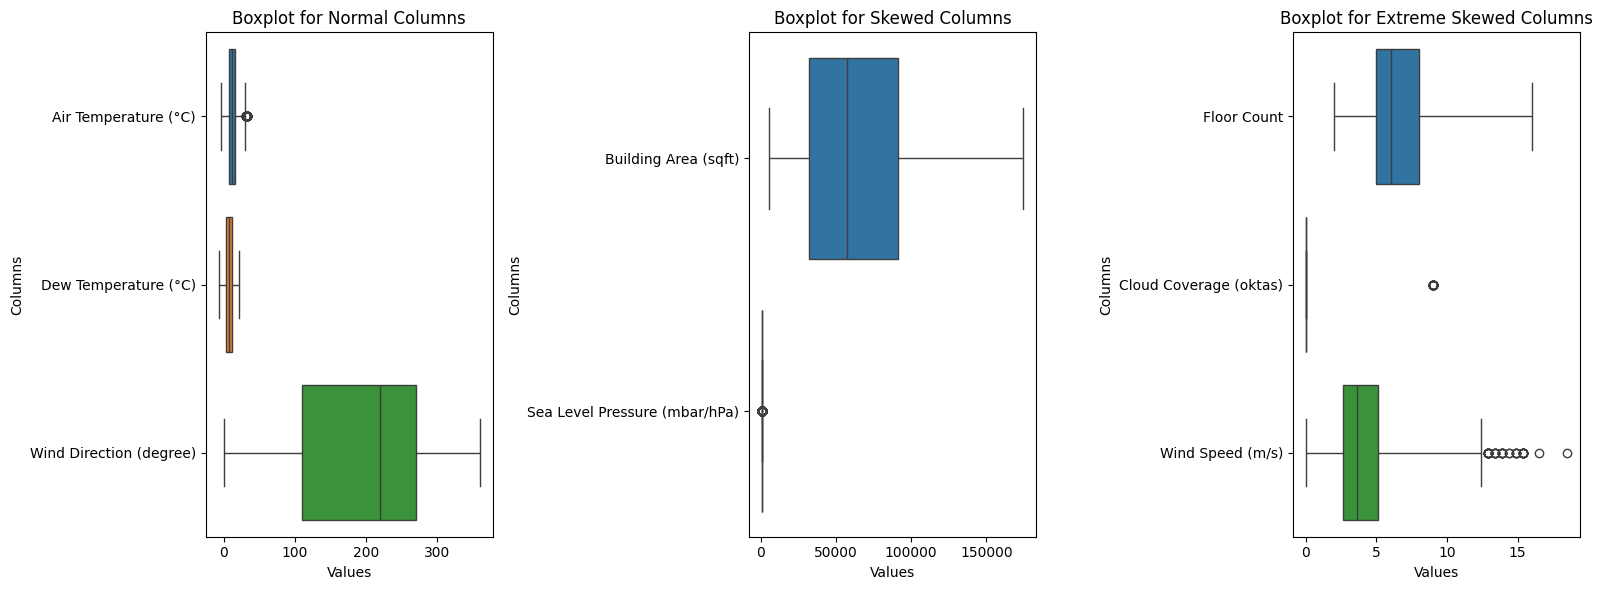

In [83]:
# Create a figure for normal, skewed, and extremely skewed columns
fig, axes = plt.subplots(ncols=3, figsize=(16, 6))

# Boxplot for normal columns
sns.boxplot(data=X_train[normal_col], orient="h", ax=axes[0])
axes[0].set_title("Boxplot for Normal Columns")
axes[0].set_xlabel("Values")
axes[0].set_ylabel("Columns")

# Boxplot for skewed columns
sns.boxplot(data=X_train[skew_col], orient="h", ax=axes[1])
axes[1].set_title("Boxplot for Skewed Columns")
axes[1].set_xlabel("Values")
axes[1].set_ylabel("Columns")

# Boxplot for extreme skewed columns
sns.boxplot(data=X_train[extreme_skew_col], orient="h", whis=3, ax=axes[2])
axes[2].set_title("Boxplot for Extreme Skewed Columns")
axes[2].set_xlabel("Values")
axes[2].set_ylabel("Columns")

# Display the plot
plt.tight_layout()
plt.show()

As seen from the figure above, there are somedetected data outliers in the normal, skewed, and extremely skewed columns. Therefore, a capping method using winsorization should be done in order to capped the outliers to be included in the data distribution range.

Now, we can do capping for the outlier in the data using winsorization.

In [84]:
# Store original data before winsorization
X_train_original = X_train.copy()
X_test_original = X_test.copy()

In [85]:
# Create function to apply winsorization for normal (Gaussian method)
def apply_winsorization_normal(train, test, variables, fold=3):
    train_capped = train.copy()
    test_capped = test.copy()

    for col in variables:
        # Calculate mean and std from training data
        mean = train[col].mean()
        std = train[col].std()

        # Calculate lower bounds and upper bounds
        lower = mean - fold * std
        upper = mean + fold * std

        # Apply to both train and test
        train_capped[col] = train[col].clip(lower, upper)
        test_capped[col] = test[col].clip(lower, upper)

    return train_capped, test_capped

# Create function to apply winsorization for skew and extreme skew (IQR method)
def apply_winsorization_skew(train, test, variables, fold=1.5):
    train_capped = train.copy()
    test_capped = test.copy()

    for col in variables:
        # Calculate IQR from training data
        Q1 = train[col].quantile(0.25)
        Q3 = train[col].quantile(0.75)
        IQR = Q3 - Q1

        # Calculate lower and upper bounds
        lower = Q1 - fold * IQR
        upper = Q3 + fold * IQR

        # Apply to both train and test
        train_capped[col] = train[col].clip(lower, upper)
        test_capped[col] = test[col].clip(lower, upper)

    return train_capped, test_capped


# Apply to X_train and X_test
X_train, X_test = apply_winsorization_normal(X_train, X_test, normal_col, fold=3)
X_train, X_test = apply_winsorization_skew(X_train, X_test, skew_col, fold=1.5)
X_train, X_test = apply_winsorization_skew(X_train, X_test, extreme_skew_col, fold=3)


The limit used for the X_test is from the calculation of the bounds using X_train.

In [86]:
# Compare before and after
print("="*90)
print("BEFORE vs AFTER WINSORIZATION COMPARISON")
print("="*90)

all_cols = normal_col + skew_col + extreme_skew_col

for col in all_cols:
    print(f"\n{col}:")
    print("-" * 60)

    # Training data comparison
    print("TRAIN:")
    print(f"  Before - Min: {X_train_original[col].min():.2f}, Max: {X_train_original[col].max():.2f}, Mean: {X_train_original[col].mean():.2f}")
    print(f"  After  - Min: {X_train[col].min():.2f}, Max: {X_train[col].max():.2f}, Mean: {X_train[col].mean():.2f}")
    print(f"  Capped values: {(X_train_original[col] != X_train[col]).sum()} out of {len(X_train)} ({(X_train_original[col] != X_train[col]).sum()/len(X_train)*100:.1f}%)")

    # Test data comparison
    print("TEST:")
    print(f"  Before - Min: {X_test_original[col].min():.2f}, Max: {X_test_original[col].max():.2f}, Mean: {X_test_original[col].mean():.2f}")
    print(f"  After  - Min: {X_test[col].min():.2f}, Max: {X_test[col].max():.2f}, Mean: {X_test[col].mean():.2f}")
    print(f"  Capped values: {(X_test_original[col] != X_test[col]).sum()} out of {len(X_test)} ({(X_test_original[col] != X_test[col]).sum()/len(X_test)*100:.1f}%)")

BEFORE vs AFTER WINSORIZATION COMPARISON

Air Temperature (°C):
------------------------------------------------------------
TRAIN:
  Before - Min: -3.90, Max: 32.90, Mean: 11.80
  After  - Min: -3.90, Max: 30.33, Mean: 11.80
  Capped values: 46 out of 15903 (0.3%)
TEST:
  Before - Min: -3.90, Max: 32.90, Mean: 11.71
  After  - Min: -3.90, Max: 30.33, Mean: 11.70
  Capped values: 13 out of 3976 (0.3%)

Dew Temperature (°C):
------------------------------------------------------------
TRAIN:
  Before - Min: -7.40, Max: 20.70, Mean: 7.70
  After  - Min: -7.40, Max: 20.70, Mean: 7.70
  Capped values: 0 out of 15903 (0.0%)
TEST:
  Before - Min: -7.40, Max: 20.70, Mean: 7.69
  After  - Min: -7.40, Max: 20.70, Mean: 7.69
  Capped values: 0 out of 3976 (0.0%)

Wind Direction (degree):
------------------------------------------------------------
TRAIN:
  Before - Min: 0.00, Max: 360.00, Mean: 194.44
  After  - Min: 0.00, Max: 360.00, Mean: 194.44
  Capped values: 0 out of 15903 (0.0%)
TEST:
  

From the data, it can be seen that the maximum/minimum value has changed after the winsorization, making the outlier be included in the now more wide-ranging bounds. However, to check whether the capping using winsorization is successful, we need to visualized the data to make sure that there are no more outliers.

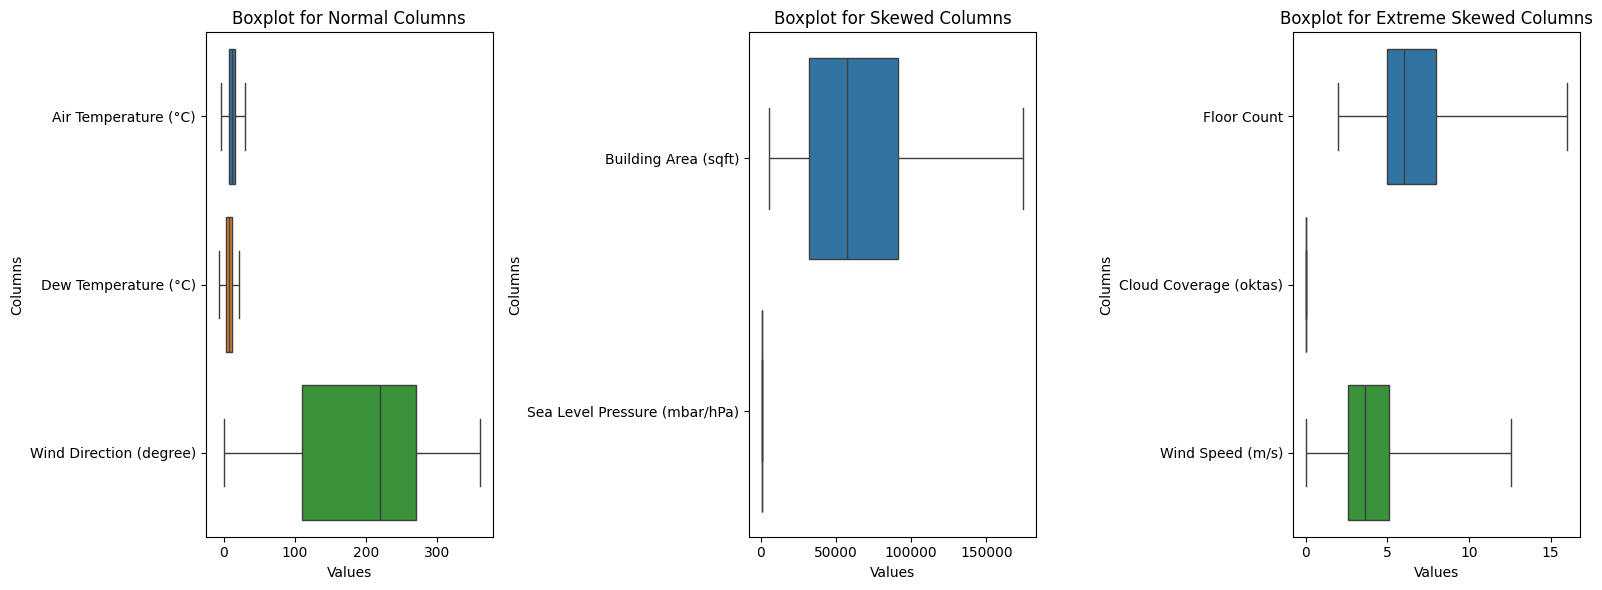

In [87]:
# Create a figure for normal, skewed, and extremely skewed columns
fig, axes = plt.subplots(ncols=3, figsize=(16, 6))

# Boxplot for normal columns
sns.boxplot(data=X_train[normal_col], orient="h", ax=axes[0])
axes[0].set_title("Boxplot for Normal Columns")
axes[0].set_xlabel("Values")
axes[0].set_ylabel("Columns")

# Boxplot for skewed columns
sns.boxplot(data=X_train[skew_col], orient="h", ax=axes[1])
axes[1].set_title("Boxplot for Skewed Columns")
axes[1].set_xlabel("Values")
axes[1].set_ylabel("Columns")

# Boxplot for extreme skewed columns
sns.boxplot(data=X_train[extreme_skew_col], orient="h", whis=3, ax=axes[2])
axes[2].set_title("Boxplot for Extreme Skewed Columns")
axes[2].set_xlabel("Values")
axes[2].set_ylabel("Columns")

# Display the plot
plt.tight_layout()
plt.show()

From the figure above, it can be seen that the detected outliers from before capping are not seen on the boxplot after being capped using winsorization. This will help to ensure that the model has more integrity.

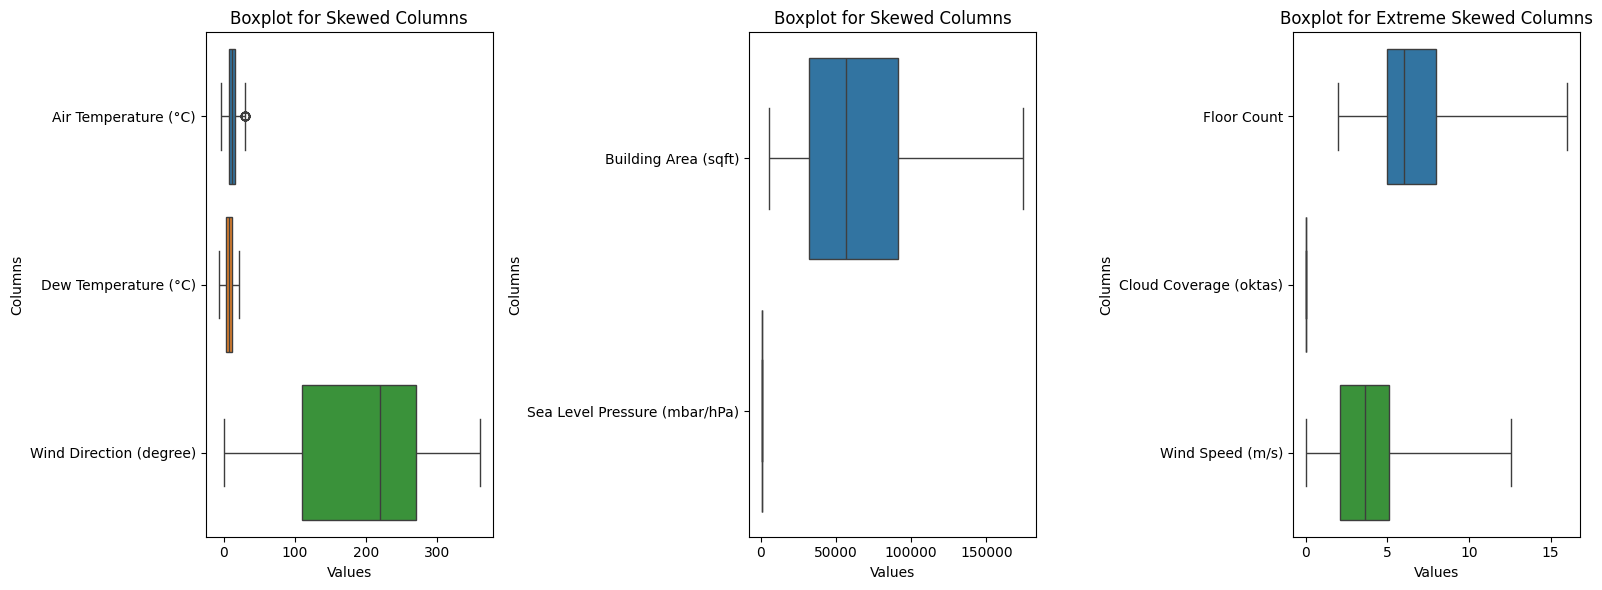

In [88]:
# Create a figure and two subplots side by side
fig, axes = plt.subplots(ncols=3, figsize=(16, 6))

# Boxplot for normal columns
sns.boxplot(data=X_test[normal_col], orient="h", ax=axes[0])
axes[0].set_title("Boxplot for Skewed Columns")
axes[0].set_xlabel("Values")
axes[0].set_ylabel("Columns")

# Boxplot for skewed columns
sns.boxplot(data=X_test[skew_col], orient="h", ax=axes[1])
axes[1].set_title("Boxplot for Skewed Columns")
axes[1].set_xlabel("Values")
axes[1].set_ylabel("Columns")

# Boxplot for extreme skewed columns
sns.boxplot(data=X_test[extreme_skew_col], orient="h", whis=3, ax=axes[2])
axes[2].set_title("Boxplot for Extreme Skewed Columns")
axes[2].set_xlabel("Values")
axes[2].set_ylabel("Columns")

# Display the plot
plt.tight_layout()
plt.show()

As seen from the figure for capped X_test, it can be seen that most of the outliers are capped by the new bounds set by the X_train. The upper and lower boundary thresholds made by X_train acts as a preventive measure to make sure that no information from X_test gets leaked to the model. Furthermore, it provides consistency to the model to have X_train and X_test have the same boundary. This is also especially important for the real data simulation where they might have a new extreme value, therefore they can be detected and held to the same treshold as from the training model.

h. Feature Selection

For feature selection, we would use several correlation techniques according to each features type in order to make sure that the correlation data is accurate.

First, we need to concat the X_train and X_test to make the correlation calculation applicable to both train data and the test data.

In [89]:
# Concatenate X_train and y_train
concat_train = pd.concat([X_train,y_train],axis=1)
#show the concated table for train set
concat_train.head()

,Building Use,Building Area (sqft),Floor Count,Air Temperature (°C),Cloud Coverage (oktas),Dew Temperature (°C),Sea Level Pressure (mbar/hPa),Wind Direction (degree),Wind Speed (m/s),Time Category,Era Category,Meter Type Category,Meter Reading (kWh)
17482,Office,34455,8,9.7,0.0,7.1,1019.2,360.0,2.1,Night,Pre-Energy Code Era (before 1981),Electricity,184.9
11349,Lodging/residential,64723,8,5.8,0.0,5.0,1031.4,150.0,1.5,Morning/Day,Pre-Energy Code Era (before 1981),Electricity,67.6
10750,Lodging/residential,102957,7,17.7,0.0,15.6,1017.2,10.0,2.6,Night,Pre-Energy Code Era (before 1981),Electricity,54.7
15776,Office,34455,8,13.6,0.0,10.0,1007.0,60.0,1.5,Night,Pre-Energy Code Era (before 1981),Electricity,208.6
291,Education,91149,7,17.6,0.0,13.7,1000.5,210.0,2.6,Afternoon/Evening,Post-Energy Code Era (after 1980),Electricity,647.0


In [90]:
concat_train.columns

Index(['Building Use', 'Building Area (sqft)', 'Floor Count',
       'Air Temperature (°C)', 'Cloud Coverage (oktas)',
       'Dew Temperature (°C)', 'Sea Level Pressure (mbar/hPa)',
       'Wind Direction (degree)', 'Wind Speed (m/s)', 'Time Category',
       'Era Category', 'Meter Type Category', 'Meter Reading (kWh)'],
      dtype='object')

Looking at the data, we have 2 data type, which is numerical and categorical. For numerical data (numerical columns) that correlates with numerical data (Meter Reading (kWh)), we can check the correlation with methods such as pearson's and spearman's. For this calculation, we will use both of the method to make sure that all ground are covered for the correlation. In principle, Pearson's method and Spearman's method are similar in nature, with Spearman's is more robust against outliers.

On the other hand, for categorical data (categorical columns) that correlate with numerical data (Meter Reading (kWh)), we can check the correlation using ANOVA instead of Kendall. This is because kendall's methos are more suitable for small sample count, instead of ANOVA, which is more robust to analyze and compared significance between categories and targets.

In [91]:
def correlation_with_meter_reading(df, target, num_cols, cat_cols):
    """
    Correlate all features with target column (Meter Reading (kWh))
    """
    results = {}

    # Get target values
    y = df[target]

    # 1. PEARSON CORRELATION (Numerical features vs Price)
    print("="*70)
    print(f"PEARSON CORRELATION WITH {target.upper()} (Linear Relationship)")
    print("="*70)

    pearson_results = []
    for col in num_cols:
        if col != target:  # Skip target column
                  corr, p_val = pearsonr(df[col], y)
                  pearson_results.append({
					'Feature': col,
					'Pearson_Correlation': corr,
					'Abs_Correlation': abs(corr),
					'p-value': p_val,
					'Significant': 'Yes' if p_val < 0.05 else 'No'
				})

    pearson_df = pd.DataFrame(pearson_results).sort_values('Abs_Correlation', ascending=False)
    print(pearson_df.to_string(index=False))
    results['pearson'] = pearson_df

    # 2. SPEARMAN CORRELATION (Numerical features vs target - handles non-linear)
    print("\n" + "="*70)
    print(f"SPEARMAN CORRELATION WITH {target.upper()} (Monotonic Relationship)")
    print("="*70)

    spearman_results = []
    for col in num_cols:
            corr, p_val = spearmanr(df[col], y)
            spearman_results.append({
				'Feature': col,
				'Spearman_Correlation': corr,
				'Abs_Correlation': abs(corr),
				'p-value': p_val,
				'Significant': 'Yes' if p_val < 0.05 else 'No'
			})

    spearman_df = pd.DataFrame(spearman_results).sort_values('Abs_Correlation', ascending=False)
    print(spearman_df.to_string(index=False))
    results['spearman'] = spearman_df

    # 3. ANOVA (Categorical features vs target)
    print("\n" + "="*70)
    print(f"ANOVA F-TEST WITH {target.upper()} (Categorical Features)")
    print("="*70)

    anova_results = []
    for col in cat_cols:
        # Create groups based on categorical values
        groups = [y[df[col] == category].dropna().values
                  for category in df[col].unique()]
        groups = [g for g in groups if len(g) > 0]  # Remove empty groups

        if len(groups) > 1:
            f_stat, p_val = f_oneway(*groups)
            anova_results.append({
                'Feature': col,
                'F-statistic': f_stat,
                'p-value': p_val,
                'Significant': 'Yes' if p_val < 0.05 else 'No'
            })

    anova_df = pd.DataFrame(anova_results).sort_values('F-statistic', ascending=False)
    print(anova_df.to_string(index=False))
    results['anova'] = anova_df

    return results

#Analyze the data
results = correlation_with_meter_reading(
    concat_train,
    target='Meter Reading (kWh)',
    num_cols=num_col,
    cat_cols=cat_col_new
)

PEARSON CORRELATION WITH METER READING (KWH) (Linear Relationship)
                      Feature  Pearson_Correlation  Abs_Correlation  p-value Significant
         Building Area (sqft)             0.552098         0.552098 0.000000         Yes
                  Floor Count             0.324700         0.324700 0.000000         Yes
         Dew Temperature (°C)            -0.032815         0.032815 0.000035         Yes
             Wind Speed (m/s)             0.029571         0.029571 0.000192         Yes
         Air Temperature (°C)            -0.010043         0.010043 0.205379          No
Sea Level Pressure (mbar/hPa)            -0.005232         0.005232 0.509422          No
      Wind Direction (degree)             0.004352         0.004352 0.583128          No
       Cloud Coverage (oktas)                  NaN              NaN      NaN          No

SPEARMAN CORRELATION WITH METER READING (KWH) (Monotonic Relationship)
                      Feature  Spearman_Correlation  Abs_Cor

C:\Users\aramd\AppData\Local\Temp\ipykernel_17492\1268448131.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = pearsonr(df[col], y)
C:\Users\aramd\AppData\Local\Temp\ipykernel_17492\1268448131.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = spearmanr(df[col], y)


From the correlation above (Pearson and ANOVA), we can see that all of the features, except Sea Level Pressure (mbar/hPa), Wind Direction (degree), and Cloud Coverage (oktas) has siginficant impact on meter reading (kWh). Furthermore, from the correlation between numerical columns and the meter reading (kWh), it can be seen that Building Area (sqft), Floor Count, Dew Temperature (°C), Air Temperature (°C), and Wind Speed (m/s) have a correlation of less than 0.6 with meter reading (kWh). Especially for Dew Temperature (°C), Air Temperature (°C), and Wind Speed (m/s). However, that features because it is still statistically significant.


In [92]:
#Drop numerical columns that is already represented in the new categorical columns
X_train = X_train.drop(['Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)', 'Cloud Coverage (oktas)'], axis = 1)
X_test = X_test.drop(['Sea Level Pressure (mbar/hPa)', 'Wind Direction (degree)', 'Cloud Coverage (oktas)'], axis = 1)

In [93]:
# Show columns
print(X_train.columns)
print(X_test.columns)

Index(['Building Use', 'Building Area (sqft)', 'Floor Count',
       'Air Temperature (°C)', 'Dew Temperature (°C)', 'Wind Speed (m/s)',
       'Time Category', 'Era Category', 'Meter Type Category'],
      dtype='object')
Index(['Building Use', 'Building Area (sqft)', 'Floor Count',
       'Air Temperature (°C)', 'Dew Temperature (°C)', 'Wind Speed (m/s)',
       'Time Category', 'Era Category', 'Meter Type Category'],
      dtype='object')


As seen from above, we can conclude that the redundant columns are being removed/dropped. Then we put the newly selected features in new variables.

In [94]:
num_col_selection = ['Building Area (sqft)', 'Floor Count', 'Air Temperature (°C)', 'Dew Temperature (°C)', 'Wind Speed (m/s)']
cat_col_selection = ['Building Use', 'Time Category', 'Era Category', 'Meter Type Category']

i. Split numerical columns and categorical columns

Now,after the feature selection, we can split the newly selected data into a new numerical and categorical column for each X_train and X_test.

In [95]:
# Separate num_col_final and cat_col_final into training and testing set for machine learning
X_train_num = X_train[num_col_selection]
X_train_cat = X_train[cat_col_selection]

X_test_num = X_test[num_col_selection]
X_test_cat = X_test[cat_col_selection]

In [96]:
print(X_train_num.columns)
print(X_train_cat.columns)
print(X_test_num.columns)
print(X_test_cat.columns)

Index(['Building Area (sqft)', 'Floor Count', 'Air Temperature (°C)',
       'Dew Temperature (°C)', 'Wind Speed (m/s)'],
      dtype='object')
Index(['Building Use', 'Time Category', 'Era Category', 'Meter Type Category'], dtype='object')
Index(['Building Area (sqft)', 'Floor Count', 'Air Temperature (°C)',
       'Dew Temperature (°C)', 'Wind Speed (m/s)'],
      dtype='object')
Index(['Building Use', 'Time Category', 'Era Category', 'Meter Type Category'], dtype='object')


As seen from above, the columns name in each train and test data is already matched our selected columns.

j. Feature scaling for numeric column

For numerical features in X_train and X_test, we will use MinMax Scaler to scale the numerical features. It is because this method is suitable for skewed numerical data, which in this case fit our case perfectly.

In [97]:
#define MinMax scaler
scaler = MinMaxScaler()
scaler.fit_transform(X_train_num)
scaler.transform(X_test_num)

#create a new scaled data frame
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num) #transform test data using the same scaller as fitted on train

#create a new scaled data frame with the sama ecolumn name as X_train and X_test
X_train_num_scaled = pd.DataFrame(
    X_train_num_scaled,
    columns=X_train_num.columns,
    index=X_train_num.index
)

X_test_num_scaled = pd.DataFrame(
    X_test_num_scaled,
    columns=X_test_num.columns,
    index=X_test_num.index
)


In [98]:
#check X_train_num_scaled
X_train_num_scaled.head()

,Building Area (sqft),Floor Count,Air Temperature (°C),Dew Temperature (°C),Wind Speed (m/s)
17482,0.171846,0.428571,0.397264,0.516014,0.166667
11349,0.350706,0.428571,0.283342,0.441281,0.119048
10750,0.576640,0.357143,0.630948,0.818505,0.206349
15776,0.171846,0.428571,0.511185,0.619217,0.119048
291,0.506864,0.357143,0.628027,0.750890,0.206349


In [99]:
#check X_train_num_scaled
X_test_num_scaled.head()

,Building Area (sqft),Floor Count,Air Temperature (°C),Dew Temperature (°C),Wind Speed (m/s)
4428,0.095523,0.214286,0.350527,0.519573,0.936508
12975,0.361396,0.571429,0.686448,0.654804,0.452381
6844,0.506864,0.357143,0.254132,0.402135,0.119048
13330,0.205115,0.142857,0.806212,0.861210,0.206349
13669,0.356226,0.428571,0.467369,0.473310,0.325397


In [100]:
X_test_num_scaled.columns

Index(['Building Area (sqft)', 'Floor Count', 'Air Temperature (°C)',
       'Dew Temperature (°C)', 'Wind Speed (m/s)'],
      dtype='object')

Now, we can see from above that the numerical data is scaled while also referred to the original column name and index. The feature scaling is done to help normalize the range of values in our independent variables. As seen from the data above, we can see that the data range is scaled within 0 to 1, which in this case reduce a lot of noise within the data value.

k. Feature encoding for category column

For now, we need to check the categorical features and determine whether to use one-hot encoding or ordinal encoding.

In [101]:
for col in X_train_cat:
    print(f"{col} --> number of category: {X_train_cat[col].nunique()}, categories: {X_train_cat[col].unique()}")


Building Use --> number of category: 5, categories: ['Office' 'Lodging/residential' 'Education' 'Public services'
 'Entertainment/public assembly']
Time Category --> number of category: 3, categories: ['Night' 'Morning/Day' 'Afternoon/Evening']
Era Category --> number of category: 3, categories: ['Pre-Energy Code Era (before 1981)' 'Post-Energy Code Era (after 1980)'
 'Unknown']
Meter Type Category --> number of category: 2, categories: ['Electricity' 'Hot Water']


From the categories above, we can conclude that all the categories are considered nominal categorical features, meaning there is no order in the categories per se. Therefore, to encode categorical features, we will use the OneHotEncoding method.

In [102]:
#Define OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore",sparse_output=False) # sparse_output=False for replacing `.toarray()`
ohe.fit_transform(X_train_cat)
ohe.transform(X_test_cat)

#create a new encoded data frame
X_train_cat_encoded = ohe.fit_transform(X_train_cat)
X_test_cat_encoded = ohe.transform(X_test_cat) #transform test data using the same encoder as fitted on train

#get feature names
feature_names = ohe.get_feature_names_out(X_train_cat.columns) #only X_train because X_test also has the same column names

#create a new encoded data frame with the same column name as X_train and X_test
X_train_cat_encoded = pd.DataFrame(
    X_train_cat_encoded,
    columns=feature_names,
    index=X_train_cat.index
)

X_test_cat_encoded = pd.DataFrame(
    X_test_cat_encoded,
    columns=feature_names,
    index=X_test_cat.index
)

In [103]:
#check X_train_cat_encoded
X_train_cat_encoded.head()

,Building Use_Education,Building Use_Entertainment/public assembly,Building Use_Lodging/residential,Building Use_Office,Building Use_Public services,Time Category_Afternoon/Evening,Time Category_Morning/Day,Time Category_Night,Era Category_Post-Energy Code Era (after 1980),Era Category_Pre-Energy Code Era (before 1981),Era Category_Unknown,Meter Type Category_Electricity,Meter Type Category_Hot Water
17482,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
11349,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
10750,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
15776,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
291,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [104]:
X_test_cat_encoded.head()

,Building Use_Education,Building Use_Entertainment/public assembly,Building Use_Lodging/residential,Building Use_Office,Building Use_Public services,Time Category_Afternoon/Evening,Time Category_Morning/Day,Time Category_Night,Era Category_Post-Energy Code Era (after 1980),Era Category_Pre-Energy Code Era (before 1981),Era Category_Unknown,Meter Type Category_Electricity,Meter Type Category_Hot Water
4428,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
12975,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
6844,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
13330,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
13669,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


From the result above, it can be seen that the data is already encoded into binary 1 and 0, in which 1 represents the presence of the categorical label, and 0 represent the lack of the categorical label presence.

In [105]:
X_test_cat_encoded.columns

Index(['Building Use_Education', 'Building Use_Entertainment/public assembly',
       'Building Use_Lodging/residential', 'Building Use_Office',
       'Building Use_Public services', 'Time Category_Afternoon/Evening',
       'Time Category_Morning/Day', 'Time Category_Night',
       'Era Category_Post-Energy Code Era (after 1980)',
       'Era Category_Pre-Energy Code Era (before 1981)',
       'Era Category_Unknown', 'Meter Type Category_Electricity',
       'Meter Type Category_Hot Water'],
      dtype='object')

In [106]:
# Prepare the data by merging the categorical and numerical column in X_train and X_test
X_train_final = pd.concat([X_train_num_scaled, X_train_cat_encoded], axis=1)
X_test_final = pd.concat([X_test_num_scaled, X_test_cat_encoded], axis=1)


As seen from above, the data is ready to get to model definition, model training, and model evaluation.

The column for numerical and categorical used for data saving for model inference.

In [107]:
num_col_selection

['Building Area (sqft)',
 'Floor Count',
 'Air Temperature (°C)',
 'Dew Temperature (°C)',
 'Wind Speed (m/s)']

In [108]:
cat_col_selection

['Building Use', 'Time Category', 'Era Category', 'Meter Type Category']

In [109]:
X_train_final.columns

Index(['Building Area (sqft)', 'Floor Count', 'Air Temperature (°C)',
       'Dew Temperature (°C)', 'Wind Speed (m/s)', 'Building Use_Education',
       'Building Use_Entertainment/public assembly',
       'Building Use_Lodging/residential', 'Building Use_Office',
       'Building Use_Public services', 'Time Category_Afternoon/Evening',
       'Time Category_Morning/Day', 'Time Category_Night',
       'Era Category_Post-Energy Code Era (after 1980)',
       'Era Category_Pre-Energy Code Era (before 1981)',
       'Era Category_Unknown', 'Meter Type Category_Electricity',
       'Meter Type Category_Hot Water'],
      dtype='object')

VI. Model Definition

For model definition, we wil use 5 regression type models definition, such as KNN Regressor, Decision Tree Regressor, SVM (SVR Linear) Regressor, Random Forest Regressor, and Histogram-based Gradient Regressor (or we would name it as Gradient Boosting for convenience sake).

In [110]:
knn_model = KNeighborsRegressor(n_neighbors=5)
det_model = DecisionTreeRegressor(random_state=34, max_depth=10)
svr_model = SVR(kernel='linear', C=1.0)
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=45)
gradient_boosting_model = HistGradientBoostingRegressor(max_iter=100, random_state=22)


In [111]:
models = {
    'KNN Regressor': knn_model,
    'Decision Tree': det_model,
    'SVR (Linear kernel)': svr_model,
    'Random Forest': random_forest_model,
    'Gradient Boosting': gradient_boosting_model,
}

From the above, we will add the 5 models used in this ML into a dictionary to make it easily accessible.

VII. Model Training

First, we need to check the intercept and coefficient for each feature in the X_train_final. The intercept would represent the baseline/threshold for the meter reading when all the features are 0 (no features).

In [112]:
print("=" * 90)
print("INTERCEPTS - Meter Reading (kWh) Baseline")
print("=" * 90)

baseline = y_train.mean()

for name, model in models.items():
    if hasattr(model, 'intercept_'):
        intercept_val = model.intercept_[0] if hasattr(model.intercept_, '__len__') else model.intercept_
        print(f"{name:30s} : {intercept_val:.6f} kWh  (model intercept)")
    else:
        print(f"{name:30s} : {baseline:.6f} kWh  (y_train mean as baseline)")


INTERCEPTS - Meter Reading (kWh) Baseline
KNN Regressor                  : 149.247375 kWh  (y_train mean as baseline)
Decision Tree                  : 149.247375 kWh  (y_train mean as baseline)
SVR (Linear kernel)            : 149.247375 kWh  (y_train mean as baseline)
Random Forest                  : 149.247375 kWh  (y_train mean as baseline)
Gradient Boosting              : 149.247375 kWh  (y_train mean as baseline)


The result above shows that the y(intercept) of the model has a meter reading baseline of `149.25`. This means that when there is no influence of features, the meter reading baseline would be 149.25.

In [113]:
# MODEL TRAINING

print("="*90)
print("MODEL TRAINING")
print("="*90)

trained_models = {}
predictions = {}
prediction_dataframes = {}

for i, (name, model) in enumerate(models.items(), 1):
    print(f"{i}. Training: {name}")

    try:
        # train model
        model.fit(X_train_final, y_train)

        # store trained model
        trained_models[name] = model

        # prediction
        y_pred = model.predict(X_test_final)
        predictions[name] = y_pred

        # create df with features + actual + prediction
        df_pred = X_test_final.copy()
        df_pred['Actual_Meter_Reading'] = y_test.values
        df_pred['Predicted_Meter_Reading'] = y_pred
        df_pred['Residual'] = y_test.values - y_pred
        df_pred['Abs_Residual'] = abs(y_test.values - y_pred)
        df_pred['Model'] = name

        # store df
        prediction_dataframes[name] = df_pred

        # save individual model to csv
        filename = f"predictions_{name.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '').lower()}.csv"
        df_pred.to_csv(filename, index=False)

        print(f"   Training completed!")
        print(f"   Predictions saved to : {filename}")
        print(f"   Test shape           : {df_pred.shape}")
        print()

    except Exception as e:
        print(f"   Error during training: {str(e)}")
        trained_models[name] = None
        predictions[name] = None
        prediction_dataframes[name] = None

MODEL TRAINING
1. Training: KNN Regressor
   Training completed!
   Predictions saved to : predictions_knn_regressor.csv
   Test shape           : (3976, 23)

2. Training: Decision Tree
   Training completed!
   Predictions saved to : predictions_decision_tree.csv
   Test shape           : (3976, 23)

3. Training: SVR (Linear kernel)
   Training completed!
   Predictions saved to : predictions_svr_linear_kernel.csv
   Test shape           : (3976, 23)

4. Training: Random Forest
   Training completed!
   Predictions saved to : predictions_random_forest.csv
   Test shape           : (3976, 23)

5. Training: Gradient Boosting
   Training completed!
   Predictions saved to : predictions_gradient_boosting.csv
   Test shape           : (3976, 23)



In [114]:
predictions_knn_regression = pd.read_csv('predictions_knn_regressor.csv', delimiter = ',')
predictions_det_regression = pd.read_csv('predictions_decision_tree.csv', delimiter = ',')
predictions_svr_regression = pd.read_csv('predictions_svr_linear_kernel.csv', delimiter = ',')
predictions_random_regression = pd.read_csv('predictions_random_forest.csv', delimiter = ',')
predictions_gradient_regression = pd.read_csv('predictions_gradient_boosting.csv', delimiter = ',')

Above we upload the prediction csv into variable for each model for comparison and evaluation.

In [115]:
predictions_knn_regression.head()

,Building Area (sqft),Floor Count,Air Temperature (°C),Dew Temperature (°C),Wind Speed (m/s),Building Use_Education,Building Use_Entertainment/public assembly,Building Use_Lodging/residential,Building Use_Office,Building Use_Public services,...,Era Category_Post-Energy Code Era (after 1980),Era Category_Pre-Energy Code Era (before 1981),Era Category_Unknown,Meter Type Category_Electricity,Meter Type Category_Hot Water,Actual_Meter_Reading,Predicted_Meter_Reading,Residual,Abs_Residual,Model
0,0.095523,0.214286,0.350527,0.519573,0.936508,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,95.6,141.72,-46.12,46.12,KNN Regressor
1,0.361396,0.571429,0.686448,0.654804,0.452381,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,37.6,30.80,6.80,6.80,KNN Regressor
2,0.506864,0.357143,0.254132,0.402135,0.119048,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,498.3,436.84,61.46,61.46,KNN Regressor
3,0.205115,0.142857,0.806212,0.861210,0.206349,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,41.1,28.92,12.18,12.18,KNN Regressor
4,0.356226,0.428571,0.467369,0.473310,0.325397,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,410.3,388.86,21.44,21.44,KNN Regressor


In [116]:
print(f"ABS Residual max - KNN regression: {predictions_knn_regression['Abs_Residual'].max()}")
print(f"ABS Residual min - KNN regression: {predictions_knn_regression['Abs_Residual'].min()}")
print(f"ABS Residual avg - KNN regression: {predictions_knn_regression['Abs_Residual'].mean()}")

ABS Residual max - KNN regression: 666.5799999999999
ABS Residual min - KNN regression: 0.0
ABS Residual avg - KNN regression: 38.784989939637825


In [117]:
print(f"ABS Residual max - Decision Tree regression: {predictions_det_regression['Abs_Residual'].max()}")
print(f"ABS Residual min - Decision Tree regression: {predictions_det_regression['Abs_Residual'].min()}")
print(f"ABS Residual avg - Decision Tree regression: {predictions_det_regression['Abs_Residual'].mean()}")

ABS Residual max - Decision Tree regression: 706.5692307692307
ABS Residual min - Decision Tree regression: 0.0
ABS Residual avg - Decision Tree regression: 28.679766720100826


In [118]:
print(f"ABS Residual max - SVR : {predictions_svr_regression['Abs_Residual'].max()}")
print(f"ABS Residual min - SVR: {predictions_svr_regression['Abs_Residual'].min()}")
print(f"ABS Residual avg - SVR: {predictions_svr_regression['Abs_Residual'].mean()}")

ABS Residual max - SVR : 836.7942169311838
ABS Residual min - SVR: 0.0148071805837872
ABS Residual avg - SVR: 79.82933967782112


In [119]:
print(f"ABS Residual max - Random forest Regressor : {predictions_random_regression['Abs_Residual'].max()}")
print(f"ABS Residual min - Random forest Regressor: {predictions_random_regression['Abs_Residual'].min()}")
print(f"ABS Residual avg - Random forest Regressor: {predictions_random_regression['Abs_Residual'].mean()}")

ABS Residual max - Random forest Regressor : 685.5440000000001
ABS Residual min - Random forest Regressor: 0.0
ABS Residual avg - Random forest Regressor: 27.112243622448982


In [120]:
print(f"ABS Residual max - Gradient Boosting Regressor : {predictions_gradient_regression['Abs_Residual'].max()}")
print(f"ABS Residual min - Gradient Boosting Regressor: {predictions_gradient_regression['Abs_Residual'].min()}")
print(f"ABS Residual avg - Gradient Boosting Regressor: {predictions_gradient_regression['Abs_Residual'].mean()}")

ABS Residual max - Gradient Boosting Regressor : 701.2826540846551
ABS Residual min - Gradient Boosting Regressor: 0.0087683081261928
ABS Residual avg - Gradient Boosting Regressor: 28.04447358805684


So, if we compare the absolute residual of average meter reading prediction between KNN Regressor model (=38.78), Decision Tree Regression Model (=28.69),  SVR model (79.83), Random Forest Regressor (=27.10), and HistGradient Boosting Regressor (=28.044), we can see that random forest and histgradient boosting has the best result in predicting the meter reading. This means that they have a much closer prediction for meter reading compared to the other model. Now, to see which one is better, we can do further model evaluation in the next section.

VIII. Model Evaluation

VIII.1. Model Evaluation For Chosen Model

Below are the evaluation of the 5 regression model to chose the best model for hypertuning.

In [121]:
print("="*100)
print("MODEL EVALUATION")
print("="*100)

regression_results = []

for i, (name, model) in enumerate(models.items(), 1):
    print(f"{i}. Evaluating: {name}")

    try:
        #train
        model.fit(X_train_final, y_train)

        #predict on train set
        y_train_pred = model.predict(X_train_final)

        #predict on test set
        y_test_pred = model.predict(X_test_final)

        #evaluate train metrics
        train_mae = mean_absolute_error(y_train, y_train_pred)
        train_mse = mean_squared_error(y_train, y_train_pred)
        train_rmse = np.sqrt(train_mse)
        train_r2 = r2_score(y_train, y_train_pred)

        #evaluate test metrics
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        test_rmse = np.sqrt(test_mse)
        test_r2 = r2_score(y_test, y_test_pred)

        # Store results
        regression_results.append({
            'Model': name,
            'Train_MAE': train_mae,
            'Test_MAE': test_mae,
            'Train_MSE': train_mse,
            'Test_MSE': test_mse,
            'Train_RMSE': train_rmse,
            'Test_RMSE': test_rmse,
            'Train_R²': train_r2,
            'Test_R²': test_r2

        })

        print(f"  TRAIN → MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}")
        print(f"  TEST  → MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")
        print(f"R² Difference (Train - Test): {(train_r2) - (test_r2):.5f}")
        print()

    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        regression_results.append({
            'Model': name,
            'Train_MAE': np.nan,
            'Test_MAE': np.nan,
            'Train_MSE': np.nan,
            'Test_MSE': np.nan,
            'Train_RMSE': np.nan,
            'Test_RMSE': np.nan,
            'Train_R²': np.nan,
            'Test_R²': np.nan
        })

#display result

results_df = pd.DataFrame(regression_results).sort_values('Test_R²', ascending=False)

print("\n" + "="*100)
print("MODEL COMPARISON (Sorted by Test R²)")
print("="*100)
print(results_df.to_string(index=False))
print()

MODEL EVALUATION
1. Evaluating: KNN Regressor
  TRAIN → MAE: 30.3853, MSE: 2901.3710, RMSE: 53.8644, R²: 0.9095
  TEST  → MAE: 38.7850, MSE: 4657.4039, RMSE: 68.2452, R²: 0.8518
R² Difference (Train - Test): 0.05771

2. Evaluating: Decision Tree
  TRAIN → MAE: 22.0305, MSE: 1451.2289, RMSE: 38.0950, R²: 0.9547
  TEST  → MAE: 28.6798, MSE: 2909.0118, RMSE: 53.9353, R²: 0.9074
R² Difference (Train - Test): 0.04731

3. Evaluating: SVR (Linear kernel)
  TRAIN → MAE: 79.6124, MSE: 16909.0578, RMSE: 130.0348, R²: 0.4725
  TEST  → MAE: 79.8293, MSE: 16754.1378, RMSE: 129.4378, R²: 0.4668
R² Difference (Train - Test): 0.00570

4. Evaluating: Random Forest
  TRAIN → MAE: 9.8138, MSE: 353.8211, RMSE: 18.8101, R²: 0.9890
  TEST  → MAE: 27.1122, MSE: 2590.4278, RMSE: 50.8962, R²: 0.9176
R² Difference (Train - Test): 0.07140

5. Evaluating: Gradient Boosting
  TRAIN → MAE: 25.1342, MSE: 1888.9092, RMSE: 43.4616, R²: 0.9411
  TEST  → MAE: 28.0445, MSE: 2582.1125, RMSE: 50.8145, R²: 0.9178
R² Differe

As seen from the model comparison above, between 5 model tested, it can be seen that HistGradient Boosting regression model fared slightly better because its R² score is above 90% with the least amount of R² difference `(=0.02325)` compared to other model such as `KNN ((= 0.05771)`, `Random Forest (= 0.0714)`, `SVR (= 0.00570)`, `Decision tree (= 0.04731)`. This means that the fit of the Histgradient Boosting model is slightly better than the other model to predict the meter reading (kwh) and that the model is also more stable compared to the the other model because there is a lower difference between train and test.


Moreover, the difference of MAE between test and train in `Histgradient Boosting model (MAE Diff= 2.91)` compared to the other models such as `KNN ((MAE Diff= 8.39)`, `Random Forest (MAE Diff= 17.29)`, `SVR (MAE Diff= 0.21)`, `Decision tree (MAE Diff= 6.64)` is obvious. **Histgradient Boosting has the smallest MAE and MAE difference** compared to other models. Eventhough SVR has the smallest MAE difference, however, the MAE value of SVR is around ~79 while the MAE value of Histgradient Boosting is around 25-28. Therefore, it is obvious that Histgradient Boosting is the best model to be chosen for the hyper tuning. The small MAE difference between train and test indicates that the prediction is mostly consistent.  

Therefore, the best model is `Histgradient Boosting Regressor model`

In [122]:
#Best model result

if len(results_df) > 0:
    best_model = results_df.iloc[0]
    print("="*90)
    print("BEST MODEL")
    print("="*90)
    print(f"Model: {best_model['Model']}")
    print(f"\nTRAIN Performance:")
    print(f"  R²:   {best_model['Train_R²']:.4f}")
    print(f"  MAE:  {best_model['Train_MAE']:.4f}")
    print(f"  MSE:  {best_model['Train_MSE']:.4f}")
    print(f"  RMSE: {best_model['Train_RMSE']:.4f}")

    print(f"\nTEST Performance:")
    print(f"  R²:   {best_model['Test_R²']:.4f}")
    print(f"  MAE:  {best_model['Test_MAE']:.4f}")
    print(f"  MSE:  {best_model['Test_MSE']:.4f}")
    print(f"  RMSE: {best_model['Test_RMSE']:.4f}")

    #check for fit
    r2_diff = best_model['Train_R²'] - best_model['Test_R²']
    print(f"\nOverfitting Check:")
    print(f"  R² Difference (Train - Test): {r2_diff:.4f}")
    print()
    if r2_diff > 0.1:
        print("Overfitting check result: Possible overfitting detected!")
    else:
        print("Overfitting check result: Model is well generalized!")

BEST MODEL
Model: Gradient Boosting

TRAIN Performance:
  R²:   0.9411
  MAE:  25.1342
  MSE:  1888.9092
  RMSE: 43.4616

TEST Performance:
  R²:   0.9178
  MAE:  28.0445
  MSE:  2582.1125
  RMSE: 50.8145

Overfitting Check:
  R² Difference (Train - Test): 0.0232

Overfitting check result: Model is well generalized!


From the `best model: Gradient Boosting`, we see that overall the model is in a really good condition, with its model passing the overfitting check. This is because the R² score difference between Train and Test is `0.0232`, which is less than 0.05. This would mean that the model has excellent generalization. Moreover, the histogram-based gradient boosting model has a high R² score above 90%, which is generally considered as the threshold for a good fit model. In conclusion, the HistGradientBoosting regressor model is the most suitable model to use for predicting house price.

In [123]:
print("="*90)
print("CONVERTING MAE OF BEST MODEL INTO % ERROR")
print("="*90)
mae_meter_reading_upper = (best_model['Test_MAE'])
mae_meter_reading_lower = (-best_model['Test_MAE'])

mae_meter_reading_upper, mae_meter_reading_lower

upper_mae_percent = (mae_meter_reading_upper - 1) * 100
lower_mae_percent = (1 - mae_meter_reading_upper) * 100

upper_mae_percent , lower_mae_percent

print(f"Upper %MAE: +{upper_mae_percent:,.2f} %")
print(f"Lower %MAE: {lower_mae_percent:,.2f} %")

CONVERTING MAE OF BEST MODEL INTO % ERROR
Upper %MAE: +2,704.45 %
Lower %MAE: -2,704.45 %


VIII.2. Hypertuning from chosen model

In this hypertuning section, we will use grid search to do hyper-tuning on several hyperparameters in the HistGradien Boosting Regressor model (the best model). The hyper parameter chosen for the Gradient Boosting Regressor model hyper-tuning is determined by our previous model training that different *max_iter* value *might* affects the HistGradient Boosting Regressor model, therefore we can try several *max_iter* value (i.e. None, 4, 6, 8) in order to find the best *max_depth* value for the parameter. Furthermore, another hyper parameter *min_samples_split* (i.e. 5,10,15) is chosen to see how the DTC model fares in higher sample split to prevent overfitting on categorical values. Lastly, hyper parameter *min_samples_leaf* is added to hyper tuning (i.e. 5, 10, 20) in order to see each leaf has enough data. Lastly, *max_features* of either 'sqrt', 'log2', or None are used to limit features considered per split, which will reduce overfitting on many ohe columns.

A. Model Hypertuning Definition

In [124]:
models_hypertuning = {
    'Gradient Boosting': (
        HistGradientBoostingRegressor(random_state=10),
        {
            'regressor__max_iter'        : [100, 200, 300],
            'regressor__max_depth'       : [3, 5, 7],
            'regressor__learning_rate'   : [0.01, 0.05, 0.1],
            'regressor__min_samples_leaf': [20, 50, 100],
            'regressor__l2_regularization': [0.0, 0.1, 1.0]
        }
    )
}

B. Model Hypertuning Training

Now, we will run the hypertuning training for the chosen model (HistGradient Boosting Regressor).

In [125]:
results_hypertuning       = {}
trained_pipes_hypertuning = {}
cv = KFold(n_splits=5, shuffle=True, random_state=23)

for i, (name, (model, param_grid)) in enumerate(models_hypertuning.items()):
    print(f"\n{'='*90}")
    print(f"GridSearch + CrossValScore for: {name}")
    print(f"{'='*90}")

    pipe_hypertuning = Pipeline(steps=[('regressor', model)])

    grid_search = GridSearchCV(
        pipe_hypertuning,
        param_grid=param_grid,
        cv=cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    try:
        #model training
        print(f"\n--- Training ---")
        grid_search.fit(X_train_final, y_train)
        best_model = grid_search.best_estimator_

        trained_pipes_hypertuning[name] = best_model

        cv_scores   = cross_val_score(best_model, X_train_final, y_train, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
        rmse_scores = np.sqrt(-cv_scores)

        print(f"   Best Params      : {grid_search.best_params_}")
        print(f"   CV RMSE per fold : {np.round(rmse_scores, 4)}")
        print(f"   CV RMSE mean     : {rmse_scores.mean():.4f}")
        print(f"   CV RMSE std      : {rmse_scores.std():.4f}")
        # ─────────────────────────────────────────────────────────

        #prediction
        y_pred = best_model.predict(X_test_final)

        df_pred = X_test_final.copy()
        df_pred['Actual_Meter_Reading']    = y_test.values
        df_pred['Predicted_Meter_Reading'] = y_pred
        df_pred['Residual']                = y_test.values - y_pred
        df_pred['Abs_Residual']            = abs(y_test.values - y_pred)
        df_pred['Model']                   = name

        filename = f"hypertuned_{name.replace(' ', '_').lower()}.csv"
        df_pred.to_csv(filename, index=False)
        print(f"   Saved to         : {filename}")

        #store results
        results_hypertuning[name] = {
            'best_params'     : grid_search.best_params_,
            'best_grid_score' : grid_search.best_score_,
            'cv_rmse_mean'    : rmse_scores.mean(),
            'cv_rmse_std'     : rmse_scores.std(),
            'predictions'     : df_pred
        }

    except Exception as e:
        print(f"   Error: {str(e)}")
        trained_pipes_hypertuning[name] = None
        results_hypertuning[name]       = None


GridSearch + CrossValScore for: Gradient Boosting

--- Training ---
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
   Best Params      : {'regressor__l2_regularization': 0.1, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__max_iter': 200, 'regressor__min_samples_leaf': 20}
   CV RMSE per fold : [46.2154 47.624  48.6509 47.537  56.5179]
   CV RMSE mean     : 49.3091
   CV RMSE std      : 3.6865
   Saved to         : hypertuned_gradient_boosting.csv


In [126]:
predictions_hypertuned_gradient_regression = pd.read_csv('hypertuned_gradient_boosting.csv', delimiter = ',')

In [127]:
predictions_hypertuned_gradient_regression.head()

,Building Area (sqft),Floor Count,Air Temperature (°C),Dew Temperature (°C),Wind Speed (m/s),Building Use_Education,Building Use_Entertainment/public assembly,Building Use_Lodging/residential,Building Use_Office,Building Use_Public services,...,Era Category_Post-Energy Code Era (after 1980),Era Category_Pre-Energy Code Era (before 1981),Era Category_Unknown,Meter Type Category_Electricity,Meter Type Category_Hot Water,Actual_Meter_Reading,Predicted_Meter_Reading,Residual,Abs_Residual,Model
0,0.095523,0.214286,0.350527,0.519573,0.936508,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,95.6,93.440904,2.159096,2.159096,Gradient Boosting
1,0.361396,0.571429,0.686448,0.654804,0.452381,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,37.6,74.772373,-37.172373,37.172373,Gradient Boosting
2,0.506864,0.357143,0.254132,0.402135,0.119048,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,498.3,467.818652,30.481348,30.481348,Gradient Boosting
3,0.205115,0.142857,0.806212,0.861210,0.206349,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,41.1,44.958182,-3.858182,3.858182,Gradient Boosting
4,0.356226,0.428571,0.467369,0.473310,0.325397,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,410.3,449.929765,-39.629765,39.629765,Gradient Boosting


In [128]:
print(f"ABS Residual max - Hypertuned Gradient Boosting : {predictions_hypertuned_gradient_regression['Abs_Residual'].max()}")
print(f"ABS Residual min - Hypertuned Gradient Boosting: {predictions_hypertuned_gradient_regression['Abs_Residual'].min()}")
print(f"ABS Residual avg - Hypertuned Gradient Boosting: {predictions_hypertuned_gradient_regression['Abs_Residual'].mean()}")

ABS Residual max - Hypertuned Gradient Boosting : 686.6236797699723
ABS Residual min - Hypertuned Gradient Boosting: 0.0001010713547486
ABS Residual avg - Hypertuned Gradient Boosting: 27.883943249447025


The comparison of the HistGradient Boosting model before and after hypertuning is as follows:

- ABS Residual max - Gradient Boosting Regressor : 701.2826540846551
- ABS Residual min - Gradient Boosting Regressor: 0.0087683081261928
- ABS Residual avg - Gradient Boosting Regressor: 28.04447358805684


- ABS Residual max - Hypertuned Gradient Boosting : 686.6236797699723
- ABS Residual min - Hypertuned Gradient Boosting: 0.0001010713547486
- ABS Residual avg - Hypertuned Gradient Boosting: 27.883943249447025


So, compared to gradientboosting model before hypertune `(=28.04)`, the hypertuned model `(=27.88)` has lower avg abs residual value, which is good. This indicates that the prediction is hypertuned model is much closer/ more accurate.

However, we need to check the whole evaluation in MAE MSE, RMSE, to be sure in the next section.

C. Model Hypertuning Evaluation

#### Final Model Evaluation

In [129]:
print("="*100)
print("MODEL EVALUATION — HYPERTUNED MODELS")
print("="*100)

metrics_list = []

for name, result in results_hypertuning.items():
    if result is None:
        continue

    df_pred = result['predictions']
    y_true  = df_pred['Actual_Meter_Reading']
    y_pred  = df_pred['Predicted_Meter_Reading']

    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)

    print(f"\nModel : {name}")
    print(f"   Best Params  : {result['best_params']}")
    print(f"   CV RMSE Mean : {result['cv_rmse_mean']:.4f}  (std: {result['cv_rmse_std']:.4f})")
    print(f"   --- Test Set ---")
    print(f"   MAE          : {mae:.4f}")
    print(f"   MSE          : {mse:.4f}")
    print(f"   RMSE         : {rmse:.4f}")
    print(f"   R²           : {r2:.4f}")

    metrics_list.append({
        'Model'          : name,
        'Best_Params'    : result['best_params'],
        'CV_RMSE_Mean'   : result['cv_rmse_mean'],
        'CV_RMSE_Std'    : result['cv_rmse_std'],
        'Test_MAE'       : mae,
        'Test_MSE'       : mse,
        'Test_RMSE'      : rmse,
        'Test_R²'        : r2,
    })

hypertuned_results = pd.DataFrame(metrics_list).sort_values('Test_R²', ascending=False).reset_index(drop=True)


MODEL EVALUATION — HYPERTUNED MODELS

Model : Gradient Boosting
   Best Params  : {'regressor__l2_regularization': 0.1, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__max_iter': 200, 'regressor__min_samples_leaf': 20}
   CV RMSE Mean : 49.3091  (std: 3.6865)
   --- Test Set ---
   MAE          : 27.8839
   MSE          : 2582.5352
   RMSE         : 50.8187
   R²           : 0.9178


In [130]:
print("="*100)
print("MODEL EVALUATION — HYPERTUNED MODELS")
print("="*100)

for name, result in results_hypertuning.items():
    if result is None:
        continue

    df_pred = result['predictions']
    y_true  = df_pred['Actual_Meter_Reading']
    y_pred  = df_pred['Predicted_Meter_Reading']

    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)

    print(f"\nModel : {name}")
    print(f"   Best Params  : {result['best_params']}")
    print(f"   CV RMSE Mean : {result['cv_rmse_mean']:.4f}  (std: {result['cv_rmse_std']:.4f})")
    print(f"   --- Test Set ---")
    print(f"   MAE          : {mae:.4f}")
    print(f"   MSE          : {mse:.4f}")
    print(f"   RMSE         : {rmse:.4f}")
    print(f"   R²           : {r2:.4f}")


MODEL EVALUATION — HYPERTUNED MODELS

Model : Gradient Boosting
   Best Params  : {'regressor__l2_regularization': 0.1, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__max_iter': 200, 'regressor__min_samples_leaf': 20}
   CV RMSE Mean : 49.3091  (std: 3.6865)
   --- Test Set ---
   MAE          : 27.8839
   MSE          : 2582.5352
   RMSE         : 50.8187
   R²           : 0.9178


As seen from the above result, the best hyperparameters for the Histogram-based Gradient Boosting Regression model are:

- l2_regularization': 0.1
- learning_rate': 0.1
- max_depth': 7
- max_iter': 200
- min_samples_leaf': 20

Moreover, the `CV RMSE Mean = 49.3091` means that the model predictions are off by 49.3091 kWh across all cross validation folds. When compared to the `test RMSE=50.8187`, **the difference between CV RMSE and test RMSE is very small (<5)! (50.8187 - 49.3091 = 1.51)**. This indicates that the model generalizes well (not overfitting). Furthermore, the model has a small `std value of 3.686`, which is within the range of `2` and `5`. This indicates that the model is consistent across all folds.

Next, we need to compare the model before hypertuning and after hypertuning to determine the final model used in data inference and model deployment.

In [131]:
#compare before hypertuning vs after hypertuning
print("="*100)
print("GRADIENT BOOSTING — NON-HYPERTUNED vs HYPERTUNED")
print("="*100)

#before hypertuning
print("\n--- NON-HYPERTUNED ---")

y_pred_before = trained_models['Gradient Boosting'].predict(X_test_final)

mae_before  = mean_absolute_error(y_test, y_pred_before)
mse_before  = mean_squared_error(y_test, y_pred_before)
rmse_before = np.sqrt(mse_before)
r2_before   = r2_score(y_test, y_pred_before)

print(f"   MAE  : {mae_before:.4f}")
print(f"   MSE  : {mse_before:.4f}")
print(f"   RMSE : {rmse_before:.4f}")
print(f"   R²   : {r2_before:.4f}")

#after hypertuning
print("\n--- HYPERTUNED ---")

y_pred_after = trained_pipes_hypertuning['Gradient Boosting'].predict(X_test_final)

mae_after  = mean_absolute_error(y_test, y_pred_after)
mse_after  = mean_squared_error(y_test, y_pred_after)
rmse_after = np.sqrt(mse_after)
r2_after   = r2_score(y_test, y_pred_after)

print(f"   MAE  : {mae_after:.4f}")
print(f"   MSE  : {mse_after:.4f}")
print(f"   RMSE : {rmse_after:.4f}")
print(f"   R²   : {r2_after:.4f}")

#improvement summary
print("\n--- IMPROVEMENT SUMMARY ---")
print(f"   MAE  improvement : {mae_before  - mae_after  :.4f}  ({'better' if mae_after  < mae_before  else 'worse'})")
print(f"   MSE  improvement : {mse_before  - mse_after  :.4f}  ({'better' if mse_after  < mse_before  else 'worse'})")
print(f"   RMSE improvement : {rmse_before - rmse_after :.4f}  ({'better' if rmse_after < rmse_before else 'worse'})")
print(f"   R²   improvement : {r2_after    - r2_before  :.4f}  ({'better' if r2_after   > r2_before   else 'worse'})")

#display
print("\n--- RESULT DISPLAY ---")
print(f"{'Metric':<10} {'Before':>12} {'After':>12} {'Change':>12}")
print("-"*50)
print(f"{'MAE':<10} {mae_before:>12.4f} {mae_after:>12.4f} {mae_before - mae_after:>+12.4f}")
print(f"{'MSE':<10} {mse_before:>12.4f} {mse_after:>12.4f} {mse_before - mse_after:>+12.4f}")
print(f"{'RMSE':<10} {rmse_before:>12.4f} {rmse_after:>12.4f} {rmse_before - rmse_after:>+12.4f}")
print(f"{'R²':<10} {r2_before:>12.4f} {r2_after:>12.4f} {r2_after - r2_before:>+12.4f}")

#compare model non-hypertuned vs hypertuned

#hypertuning impact
print("\n--- HYPERTUNING IMPACT ---")

improved_count = sum([
    mae_after  < mae_before,
    mse_after  < mse_before,
    rmse_after < rmse_before,
    r2_after   > r2_before
])

#hypertuning impact
if improved_count == 4:
    print("Hypertuning improved ALL metrics → use AFTER hypertuned model")
elif improved_count >= 2:
    print("Hypertuning improved SOME metrics → use AFTER hypertuned model")
elif improved_count == 0:
    print("Hypertuning did NOT improve anything  → use BEFORE hypertuned model")
else:
    print("Hypertuning showed MIXED results → compare MAE and R² to decide")

#final recommendation
print("\n--- FINAL RECOMMENDATION ---")

if mae_after < mae_before and r2_after > r2_before:
    print(f"USE AFTER HYPERTUNING")
    print(f"MAE improved : {mae_before:.4f} → {rmse_after:.4f}  ({((mae_before - mae_after) / mae_before * 100):.2f}% better)")
    print(f"R² improved : {r2_before:.4f} → {r2_after:.4f}  ({((r2_after - r2_before) / r2_before * 100):.2f}% better)")
elif mae_before < mae_after and r2_before > r2_after:
    print(f"USE BEFORE HYPERTUNING")
    print(f"MAE was better : {mae_before:.4f} vs {mae_after:.4f}")
    print(f"R² was better : {r2_before:.4f} vs {r2_after:.4f}")
else:
    print(f"MIXED RESULTS — recommend using HYPERTUNED MODEL as default")
    print(f"Review RMSE and R² manually to make final decision")

print(f"\nBest Params after tuning : {results_hypertuning['Gradient Boosting']['best_params']}")
print("="*90)

GRADIENT BOOSTING — NON-HYPERTUNED vs HYPERTUNED

--- NON-HYPERTUNED ---
   MAE  : 28.0445
   MSE  : 2582.1125
   RMSE : 50.8145
   R²   : 0.9178

--- HYPERTUNED ---
   MAE  : 27.8839
   MSE  : 2582.5352
   RMSE : 50.8187
   R²   : 0.9178

--- IMPROVEMENT SUMMARY ---
   MAE  improvement : 0.1605  (better)
   MSE  improvement : -0.4227  (worse)
   RMSE improvement : -0.0042  (worse)
   R²   improvement : -0.0000  (worse)

--- RESULT DISPLAY ---
Metric           Before        After       Change
--------------------------------------------------
MAE             28.0445      27.8839      +0.1605
MSE           2582.1125    2582.5352      -0.4227
RMSE            50.8145      50.8187      -0.0042
R²               0.9178       0.9178      -0.0000

--- HYPERTUNING IMPACT ---
Hypertuning showed MIXED results → compare MAE and R² to decide

--- FINAL RECOMMENDATION ---
MIXED RESULTS — recommend using HYPERTUNED MODEL as default
Review RMSE and R² manually to make final decision

Best Params after

As seen from the result above, the model after hypertuning showed mixed results, as in some variables, like MAE, the value is improved, indicating that the hypertuned model are getting closer prediction. However, the hypertuned model is also more sensitive towards outliers, as seen by the values of MSE and RMSE that are getting worse.



#### Final Model Features Importance

Now, we can see for our final model (hypertuned HistGradient Boosting Regressor), which one is their strengh and weakness in predicting the meter readings.

In [132]:
#FINAL MODEL FOR INFERENCE
model_inference = HistGradientBoostingRegressor(l2_regularization= 0.1, learning_rate= 0.1, max_depth= 7, max_iter=200, min_samples_leaf= 20, random_state=22)

In [133]:
print("=" * 100)
print("INTERCEPTS (y) - Meter Reading (kWh) Baseline")
print("=" * 100)

baseline = y_train.mean()

if not isinstance(model_inference, dict):
    model_inference = {'HistGradientBoostingRegressor': model_inference}

for name, model in model_inference.items():
    if hasattr(model, 'intercept_'):
        intercept_val = model.intercept_[0] if hasattr(model.intercept_, '__len__') else model.intercept_
        print(f"{name:30s} : {intercept_val:.6f} kWh  (model intercept)")
    else:
        print(f"{name:30s} : {baseline:.6f} kWh  (y_train mean as baseline)")

INTERCEPTS (y) - Meter Reading (kWh) Baseline
HistGradientBoostingRegressor  : 149.247375 kWh  (y_train mean as baseline)


The result above shows that the hypertuned final model (HistGradient Boosting Regressor) has a baseline meter reading of 149.24 kWh, meaning that it is the value of meter readings without influence from all features (features=0). To determine which features strongly influence our final model, we can see the result below:

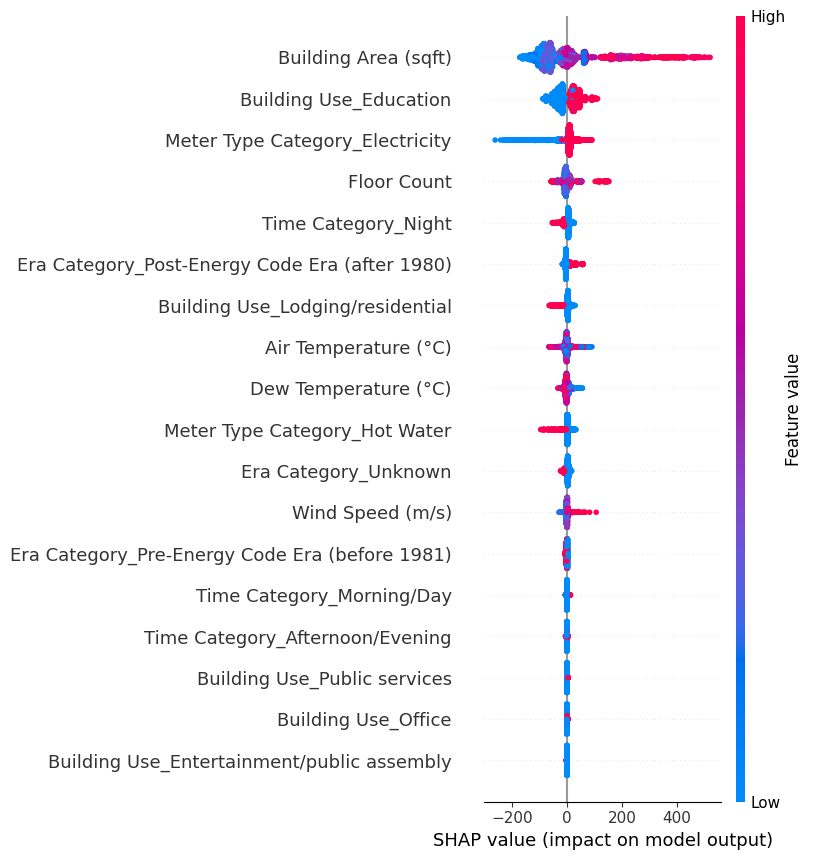

In [134]:
#model load
model_inference = HistGradientBoostingRegressor(
    l2_regularization=0.1,
    learning_rate=0.1,
    max_depth=7,
    max_iter=200,
    min_samples_leaf=20,
    random_state=22
)

#fit model first
model_inference.fit(X_train_final, y_train)

#fitted model
explainer   = shap.TreeExplainer(model_inference)
shap_values = explainer.shap_values(X_test_final)

shap.summary_plot(shap_values, X_test_final)

As seen from the figure above, our final model has a **strong point** in predicting meter readings from the top 5 features, such as `Building Area (sqft)`, `building use for education`, `electricity (0) meter type`, and `floor counts`, as well as during the `night (time category`. On the other hand, the **weak point** of this final model are for features such as `building use in entertainment, public service, and office` have almost zero impact. Predictions during the `afternoon/evening time category` also have a very small impact on predicting the meter readings.

#### Improvements For Final Model

The current final model has a performance of:

   MAE  : 27.8839  

   MSE  : 2582.5352

   RMSE : 50.8187

   R²   : 0.9178

The `MAE value (=27.8839)` indicates that on average the prediction is off by 27.88 kWh, which is still quiet good all things considered. Furthermore, `RMSE (=50.81)` indicates that some large errors exist, probably because it is sensitive to outliers. However, `the R² (=0.9178)` value in the final model indicates the model already explains 91.78% of the variance, which means that the model is already quite good. Some suggestions that might help in **improving the model prediction** are as follows:

1. **Do more feature engineering** by creating interaction features from the original feature. For example, since building area has a strong impact on the prediction of meter reading, we can create new features based on that, such as 'area_per_floor'of 'log_area'.

2. According to the feature importance in the final model, there are several weak features such as time_category_afternoon/evening, building use_office, building use_public service, and building use_entertainment/public assembly. This means we can **drop the weak features** to reduce noise.

3. **Add more hyperparameters** to the hypertuning for the final model to see if the model could be improved, for example, by adding a hyperparameter like max_leaf_nodes to control how many final prediction box/leaf a tree can have. Usually, more leaf means that the model can learn more complex data, but also have risk of memorizing the data (overfitting).

4. Handle outliers more by **capping extreme outliers**, for example, the top 1% or using quantile 0.99 (99%), and see if it improves the model or not.

5. Lastly, by **normalizing the target (y) using a log transformation**, which in this case is the 'Meter Reading (kWh)'. This is because the meter readings varies greatly between building use, therefore normalizing it using a log transform will help in minimizing bias toward certain variables.


D. Checking Assumption: Multivariate Normality from the best model

In [135]:
predictions_hypertuned_gradient_regression = pd.read_csv('hypertuned_gradient_boosting.csv', delimiter = ',')

In [136]:
predictions_hypertuned_gradient_regression.head()

,Building Area (sqft),Floor Count,Air Temperature (°C),Dew Temperature (°C),Wind Speed (m/s),Building Use_Education,Building Use_Entertainment/public assembly,Building Use_Lodging/residential,Building Use_Office,Building Use_Public services,...,Era Category_Post-Energy Code Era (after 1980),Era Category_Pre-Energy Code Era (before 1981),Era Category_Unknown,Meter Type Category_Electricity,Meter Type Category_Hot Water,Actual_Meter_Reading,Predicted_Meter_Reading,Residual,Abs_Residual,Model
0,0.095523,0.214286,0.350527,0.519573,0.936508,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,95.6,93.440904,2.159096,2.159096,Gradient Boosting
1,0.361396,0.571429,0.686448,0.654804,0.452381,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,37.6,74.772373,-37.172373,37.172373,Gradient Boosting
2,0.506864,0.357143,0.254132,0.402135,0.119048,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,498.3,467.818652,30.481348,30.481348,Gradient Boosting
3,0.205115,0.142857,0.806212,0.861210,0.206349,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,41.1,44.958182,-3.858182,3.858182,Gradient Boosting
4,0.356226,0.428571,0.467369,0.473310,0.325397,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,410.3,449.929765,-39.629765,39.629765,Gradient Boosting


In [137]:
# Get residuals

y_test_residuals = predictions_hypertuned_gradient_regression['Residual']
y_test_residuals

0        2.159096
1      -37.172373
2       30.481348
3       -3.858182
4      -39.629765
          ...    
3971    12.435507
3972   -34.582918
3973   -22.215661
3974   -28.365162
3975    -3.044419
Name: Residual, Length: 3976, dtype: float64

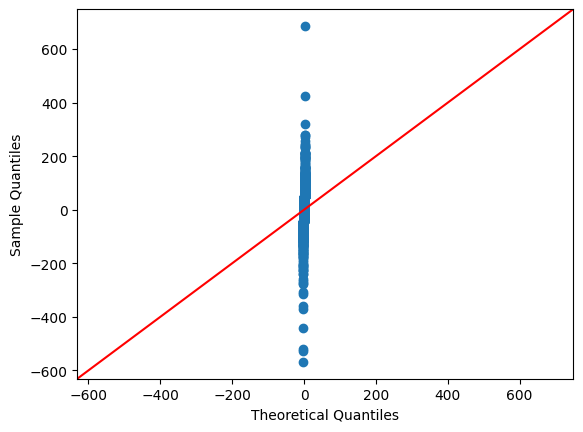

In [138]:
# Display QQ plot
import statsmodels.api as sm

sm.qqplot(y_test_residuals, line ='45')
plt.show()

As observed from the figure above, **the QQ plot is shaped vertically**.  Ideally, the QQ plot should have been a straight line, going from bottom left to top right. The result means that the assumption is violated, indicating that we have a problem, whether in missing some variables or the relationship between the sample and theoretical quantiles. This result indicates that the model residuals are not normally distributed (extreme outliers). Furthermore, it might be because the model has a heavy-tailed distribution, which is explained by the lower MAE (most prediction are close to the actual) but high RMSE (extreme outliers inflating the RMSE value). Some of the reason might be because there is extreme energy consumption within building use that might affect the prediction.

E. Checking Assumption: No Auto-Correlation from the best model

In [139]:
# Perform Durbin-Watson test
durbin_watson(y_test_residuals)

1.978020779426793

The Durbin-Watson test statistic result is `1.97`, which is within the range of `1.5` and `2.5`. Therefore, it could be concluded that the autocorrelation in this model is not a concern, indicating that the residuals are independent. This means that the ideal condition is that there would be no pattern among the consecutive residuals.

F. Checking for Homoscedasticity from the best model

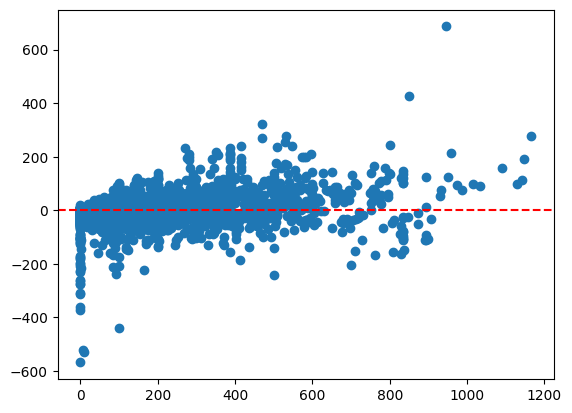

In [140]:
# Check homoscedasticioty

plt.scatter(y_test, y_test_residuals)
plt.axhline(y = 0, color = 'r', linestyle = '--')
plt.show()

As observed from the figure above, it can be seen that the `y_test_residuals` and `y_test` do not generally have a linear pattern that tends to go up, they kind of scatter along the line 0. This means there is (kinda) no heteroscedasticity. This assumption is not (kinda) violated, indicating that the error is not constant along the values of the dependent variable. Homoscedasticity means a constant error, where we are looking for a constant deviation of the points from the zero-line. If homoscedasticity is violated, this means the data has heteroscedasticity. Generally, non-constant variance arises in the presence of outliers or extreme leverage values.

IX. Model Saving

Building the final pipeline for data inference:

In [141]:
#FINAL MODEL FOR INFERENCE
model_inference = HistGradientBoostingRegressor(l2_regularization= 0.1, learning_rate= 0.1, max_depth= 7, max_iter=200, min_samples_leaf= 20, random_state=22)

Above are the final model with hyperparameter that is obtained from the hypertuning process. This model will be used as final model for data inference and deployment app.

However, to help with processing the inference data to be ready for encoding and scaling, we need to make the inference data features/columns similar to those in the feature selection. In order to do that, we need to apply the same logic that we use during the feature selection on our training data to the inference data. The function below contains the same feature selection used for the training and test data. This function will also be applied to the inference data during model inference/app deployment.

In [142]:
#function for pre-processing features
def preprocess_inference_data(data):
    """
    To apply the same feature engineering as training data
    """
    df = data.copy()

    # to ensure Time Stamp is datetime
    df['Time Stamp'] = pd.to_datetime(df['Time Stamp'])

    # to extract time only
    df['Time'] = df['Time Stamp'].dt.time

    # to categorize time based on hour
    def categorize_time(hour):
        if 6 <= hour < 14:
            return 'Morning/Day'
        elif 14 <= hour < 22:
            return 'Afternoon/Evening'
        else:
            return 'Night'

    df['Time Category'] = df['Time Stamp'].dt.hour.apply(categorize_time)

    # to categorize based on era
    def categorize_era(year):
        if year < 1981:
            return 'Pre-Energy Code Era (before 1981)'
        elif year > 1980:
            return 'Post-Energy Code Era (after 1980)'

    df['Era Category'] = df['Year Built'].apply(categorize_era)

    # meter type category
    def categorize_meter(row):
        if row['Meter Type'] == 0:
            return 'Electricity'
        elif row['Meter Type'] == 3:
            return 'Hot Water'

    df['Meter Type Category'] = df.apply(categorize_meter, axis=1)

    return df

Now, we need to make a pipeline that contains our working flow in feature engineering (feature encoding + scaling) to pre-processed the inference data and make it ready for predicting meter reading (kwh) using our final model (HistGradient Boosting Regressor).

In [143]:
#define columns num_col and cat_col from after feature selection
num_col = ['Building Area (sqft)','Floor Count','Air Temperature (°C)','Dew Temperature (°C)','Wind Speed (m/s)']
cat_col = ['Building Use', 'Time Category', 'Era Category', 'Meter Type Category']
X_train #after feature selection, before being encoded and scaled

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_col),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_col)
    ]
)

pipeline_inference = ImbPipeline([
    ('preprocessor', preprocessor),
    ('regressor', model_inference)
])
# Fit the entire pipeline
pipeline_inference.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['Building Area (sqft)',
                                                   'Floor Count',
                                                   'Air Temperature (°C)',
                                                   'Dew Temperature (°C)',
                                                   'Wind Speed (m/s)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Building Use',
                                                   'Time Category',
                                                   'Era Category',
                                                   'Meter Type Category'])])),
                ('regressor',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_depth=7, max_iter=200,
                                               random_state=22))])

In [ ]:
#model saving
with open('pipelines_inference.pkl','wb') as file_1:
  pickle.dump(pipeline_inference,file_1)

with open('num_col.txt','w') as file_2:
  json.dump(num_col_selection,file_2)

with open('cat_col.txt','w') as file_3:
  json.dump(cat_col_selection,file_3)

with open('preprocessing_function.pkl', 'wb') as file_4:
    dill.dump(preprocess_inference_data, file_4)

with open('scaler.pkl','wb') as file_5:
  pickle.dump(scaler,file_5)

with open('encoder.pkl','wb') as file_6:
  pickle.dump(ohe,file_6)

with open('model_inf.pkl','wb') as file_7:
  pickle.dump(model_inference,file_7)

joblib.dump(pipeline_inference, 'pipelines_inference_st.pkl')

['pipelines_inference_st.pkl']

The model saving above would be used for app deployment (hugging face) and data inference (ipynb).

# XI. Model Inference

The predicted meter reading (kWh) from the inference data are :

Data 1 | nan | Public services | 00:00:00 | meter readings: 21 kwh

Data 2 | 1968.0 | Education | 09:00:00 | meter readings: 469 kwh

Data 3 | 1997.0 | Office | 09:00:00 | meter readings: 55 kwh

Data 4 | 1956.0 | Lodging/residential | 19:00:00 | meter readings: 115 kwh

Data 5 | 1967.0 | Entertainment/public assembly | 23:00:00 | meter readings: 46 kwh

In [145]:
hypertuned_results

,Model,Best_Params,CV_RMSE_Mean,CV_RMSE_Std,Test_MAE,Test_MSE,Test_RMSE,Test_R²
0,Gradient Boosting,"{'regressor__l2_regularization': 0.1, 'regress...",49.309067,3.686492,27.883943,2582.53519,50.81865,0.917808


In [146]:
print("="*90)
print("CONVERTING MAE OF FINAL MODEL INTO % ERROR")
print("="*90)

# Grab only the best model (first row after sorting by Test_R²)
best_model = hypertuned_results.iloc[0]

mae_meter_reading_upper =  best_model['Test_MAE']
mae_meter_reading_lower = -best_model['Test_MAE']

upper_mae_percent = (mae_meter_reading_upper / y_test.mean()) * 100
lower_mae_percent = (mae_meter_reading_lower / y_test.mean()) * 100

print(f"Best Model   : {best_model['Model']}")
print(f"Upper %MAE   : +{upper_mae_percent:,.2f} %")
print(f"Lower %MAE   : {lower_mae_percent:,.2f} %")

CONVERTING MAE OF FINAL MODEL INTO % ERROR
Best Model   : Gradient Boosting
Upper %MAE   : +18.98 %
Lower %MAE   : -18.98 %


In [147]:
# Calculate meter readings error

predicted_inference_meter_reading = np.array([21, 469, 55, 115, 46])
mae_error = upper_mae_percent

error = (mae_error / 100) * predicted_inference_meter_reading

print(f"{'='*90}")
print(f"METER READING ERROR RANGE — BASED ON BEST MODEL MAE ({mae_error:.2f}%)")
print(f"{'='*90}")

for reading, err in zip(predicted_inference_meter_reading, error):
    print(f"\n  Predicted Reading : {reading:,.0f} kWh")
    print(f"  Range Error       : +/- {err:,.2f} kWh")
    print(f"  Upper Estimate    : {reading + err:,.2f} kWh")
    print(f"  Lower Estimate    : {reading - err:,.2f} kWh")

METER READING ERROR RANGE — BASED ON BEST MODEL MAE (18.98%)

  Predicted Reading : 21 kWh
  Range Error       : +/- 3.99 kWh
  Upper Estimate    : 24.99 kWh
  Lower Estimate    : 17.01 kWh

  Predicted Reading : 469 kWh
  Range Error       : +/- 89.03 kWh
  Upper Estimate    : 558.03 kWh
  Lower Estimate    : 379.97 kWh

  Predicted Reading : 55 kWh
  Range Error       : +/- 10.44 kWh
  Upper Estimate    : 65.44 kWh
  Lower Estimate    : 44.56 kWh

  Predicted Reading : 115 kWh
  Range Error       : +/- 21.83 kWh
  Upper Estimate    : 136.83 kWh
  Lower Estimate    : 93.17 kWh

  Predicted Reading : 46 kWh
  Range Error       : +/- 8.73 kWh
  Upper Estimate    : 54.73 kWh
  Lower Estimate    : 37.27 kWh


As observed from the result above, each data inference has a range of meter reading prediction, by accounting for %reading error (+/- 18.98%):

Data 1 | nan | Public services | 00:00:00 | meter readings range: 17.01 - 24.99  kwh

Data 2 | 1968.0 | Education | 09:00:00 | meter readings range: 379.97 - 558.03  kwh

Data 3 | 1997.0 | Office | 09:00:00 | meter readings range: 44.56 - 65.44 kwh

Data 4 | 1956.0 | Lodging/residential | 19:00:00 | meter readings range: 93.17 - 136.83 kwh

Data 5 | 1967.0 | Entertainment/public assembly | 23:00:00 | meter readings range: 37.27 - 54.73 kwh

It can be observed that the higher the energy usage, the larger the gap between predicted meter readings.

XI. Conclusions

1. The highest fit model (R² score > 90%) is a meter reading prediction,
   MAE  : 27.8839  

   MSE  : 2582.5352

   RMSE : 50.8187

   R²   : 0.9178

3. With % MAE for meter reading around 18%

4. As seen from the figure above, our final model has a **strong point** in predicting meter readings from the top 5 features, such as `Building Area (sqft)`, `building use for education`, `electricity (0) meter type`, and `floor counts`, as well as during the `night (time category`. On the other hand, the **weak point** of this final model are for features such as `building use in entertainment, public service, and office` have almost zero impact. Predictions during the `afternoon/evening time category` also have a very small impact on predicting the meter readings.,

5. Further improvement:

**Do more feature engineering** by creating interaction features from the original feature. For example, since building area has a strong impact on the prediction of meter reading, we can create new features based on that, such as 'area_per_floor'of 'log_area'.

 According to the feature importance in the final model, there are several weak features such as time_category_afternoon/evening, building use_office, building use_public service, and building use_entertainment/public assembly. This means we can **drop the weak features** to reduce noise.

**Add more hyperparameters** to the hypertuning for the final model to see if the model could be improved, for example, by adding a hyperparameter like max_leaf_nodes to control how many final prediction box/leaf a tree can have. Usually, more leaf means that the model can learn more complex data, but also have risk of memorizing the data (overfitting).

Handle outliers more by **capping extreme outliers**, for example, the top 1% or using quantile 0.99 (99%), and see if it improves the model or not.

Lastly, by **normalizing the target (y) using a log transformation**, which in this case is the 'Meter Reading (kWh)'. This is because the meter readings varies greatly between building use, therefore normalizing it using a log transform will help in minimizing bias toward certain variables.

